# Сборный проект №2

## Описание проекта

HR-аналитики компании «Работа с заботой» помогают бизнесу оптимизировать управление персоналом: бизнес предоставляет данные, а аналитики предлагают, как избежать финансовых потерь и оттока сотрудников. 

## Введение

**Исходные данные:**
Данные с характеристиками сотрудников компании. Среди них — уровень удовлетворённости сотрудника работой в компании. Эту информацию получили из форм обратной связи: сотрудники заполняют тест-опросник, и по его результатам рассчитывается доля их удовлетворённости от 0 до 1, где 0 — совершенно неудовлетворён, 1 — полностью удовлетворён.

**Цель работы:**
1. Построить модель, которая сможет предсказать уровень удовлетворённости сотрудника на основе данных заказчика.
2. Построить модель, которая сможет на основе данных заказчика предсказать то, что сотрудник уволится из компании.

**План исследования:**

Для задачи 1 и 2:
1. Загрузить и выполнить предобработку данных. 
2. Выполнить исследовательский анализ данных. 
3. Выполнить корреляционный анализ. 

Для задачи 1:

4. Обучить модели линейной регрессии и дерева решений. 

Для задачи 2:

5. Обучить как минимум 3 модели и подобрать к ним гиперпараметры. 

## Задача 1. Предсказание уровня удовлетворенности работников

### Загрузка данных

In [1]:
# !pip install -q phik
# !pip install -q shap
# !pip install -q matplotlib==3.5.0
# !pip install -q scikit-learn==1.5

In [2]:
# импортируем все необходимые библиотеки
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.utils.class_weight import compute_class_weight
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from sklearn.inspection import permutation_importance

from sklearn.model_selection import RandomizedSearchCV
from sklearn.linear_model import LinearRegression,LogisticRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    OneHotEncoder, 
    OrdinalEncoder, 
    StandardScaler, 
    MinMaxScaler, 
    RobustScaler
)
from sklearn.metrics import (
    confusion_matrix,
    make_scorer,
    r2_score, 
    mean_absolute_error, 
    mean_squared_error,
#     root_mean_squared_error, 
    roc_auc_score,
    f1_score
)

from phik import phik_matrix
from phik.report import plot_correlation_matrix

In [3]:
# введем константы
RANDOM_STATE = 42
TEST_SIZE = 0.25

warnings.filterwarnings('ignore')

In [4]:
# открываем файлы с данными 
try:
    train_job_satisfaction_rate = pd.read_csv('datasets/train_job_satisfaction_rate.csv')
    test_features = pd.read_csv('datasets/test_features.csv')
    test_target_job_satisfaction_rate = pd.read_csv('datasets/test_target_job_satisfaction_rate.csv')
except:
    train_job_satisfaction_rate = pd.read_csv('/datasets/train_job_satisfaction_rate.csv')
    test_features = pd.read_csv('/datasets/test_features.csv')
    test_target_job_satisfaction_rate = pd.read_csv('/datasets/test_target_job_satisfaction_rate.csv')

#### train_job_satisfaction_rate

In [5]:
# Выведем на экран 10 строк из набора данных
train_job_satisfaction_rate.head(10)

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate
0,155278,sales,junior,medium,2,no,no,1,24000,0.58
1,653870,hr,junior,high,2,no,no,5,38400,0.76
2,184592,sales,junior,low,1,no,no,2,12000,0.11
3,171431,technology,junior,low,4,no,no,2,18000,0.37
4,693419,hr,junior,medium,1,no,no,3,22800,0.20
5,405448,hr,middle,low,7,no,no,4,30000,0.78
6,857135,sales,sinior,medium,9,no,no,3,56400,0.56
7,400657,purchasing,middle,high,9,no,no,3,52800,0.44
8,198846,hr,junior,low,1,no,no,2,13200,0.14
9,149797,technology,middle,high,6,no,no,3,54000,0.47


In [6]:
# Выведем основную информацию о датафрейме 
train_job_satisfaction_rate.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     4000 non-null   int64  
 1   dept                   3994 non-null   object 
 2   level                  3996 non-null   object 
 3   workload               4000 non-null   object 
 4   employment_years       4000 non-null   int64  
 5   last_year_promo        4000 non-null   object 
 6   last_year_violations   4000 non-null   object 
 7   supervisor_evaluation  4000 non-null   int64  
 8   salary                 4000 non-null   int64  
 9   job_satisfaction_rate  4000 non-null   float64
dtypes: float64(1), int64(4), object(5)
memory usage: 312.6+ KB


#### test_features

In [7]:
# Выведем на экран 10 строк из набора данных
test_features.head(10)

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary
0,485046,marketing,junior,medium,2,no,no,5,28800
1,686555,hr,junior,medium,1,no,no,4,30000
2,467458,sales,middle,low,5,no,no,4,19200
3,418655,sales,middle,low,6,no,no,4,19200
4,789145,hr,middle,medium,5,no,no,5,40800
5,429973,purchasing,middle,medium,6,no,no,3,42000
6,850699,technology,junior,medium,3,no,no,3,26400
7,500791,sales,middle,high,9,no,no,4,49200
8,767867,marketing,middle,high,3,no,yes,4,62400
9,937235,sales,junior,medium,1,no,yes,3,26400


In [8]:
# Выведем основную информацию о датафрейме 
test_features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   id                     2000 non-null   int64 
 1   dept                   1998 non-null   object
 2   level                  1999 non-null   object
 3   workload               2000 non-null   object
 4   employment_years       2000 non-null   int64 
 5   last_year_promo        2000 non-null   object
 6   last_year_violations   2000 non-null   object
 7   supervisor_evaluation  2000 non-null   int64 
 8   salary                 2000 non-null   int64 
dtypes: int64(4), object(5)
memory usage: 140.8+ KB


#### test_target_job_satisfaction_rate

In [9]:
# Выведем на экран 10 строк из набора данных
test_target_job_satisfaction_rate.head(10)

,id,job_satisfaction_rate
0,130604,0.74
1,825977,0.75
2,418490,0.60
3,555320,0.72
4,826430,0.08
5,817219,0.76
6,269033,0.64
7,962356,0.38
8,649052,0.14
9,532834,0.59


In [10]:
# Выведем основную информацию о датафрейме 
test_target_job_satisfaction_rate.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     2000 non-null   int64  
 1   job_satisfaction_rate  2000 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 31.4 KB


#### Вывод по результатам загрузки данных

По результатам загрузки данных выявлено, что не требуется:
- переименование столбцов;
- изменение типов данных столбцов.

Однако, необходимо:
- проверить наличие пропусков; 
- проверить наличие дубликатов.

### Предобработка данных

In [11]:
# зададим id в качестве индексов датафреймов, чтобы по ним соединять таблицы в дальнейшем
train_job_satisfaction_rate = train_job_satisfaction_rate.set_index('id').rename_axis(index=None)
test_features = test_features.set_index('id').rename_axis(index=None)
test_target_job_satisfaction_rate = test_target_job_satisfaction_rate.set_index('id').rename_axis(index=None)

# для удобства анализа объединим тестовую признаки с таргетом
test = test_features.join(test_target_job_satisfaction_rate)

#### Обработка пропусков

In [12]:
# создадим функцию для вывода количества пропусков
def find_omissions(df):
    tmp = df.copy()
    
    missing = (pd.DataFrame({'Количество пропусков': tmp.isnull().sum(), 'Доля пропусков, %': tmp.isnull().mean().round(4)*100})
           .style.background_gradient(cmap='YlOrRd', low=0.5, high=0.3))
    return missing

In [13]:
find_omissions(train_job_satisfaction_rate)

,Количество пропусков,"Доля пропусков, %"
dept,6,0.150000
level,4,0.100000
workload,0,0.000000
employment_years,0,0.000000
last_year_promo,0,0.000000
last_year_violations,0,0.000000
supervisor_evaluation,0,0.000000
salary,0,0.000000
job_satisfaction_rate,0,0.000000


In [14]:
train_job_satisfaction_rate[train_job_satisfaction_rate['dept'].isna()]

,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate
694746,NaN,junior,medium,5,no,no,4,21600,0.62
814624,NaN,junior,medium,3,no,no,4,24000,0.88
475114,NaN,junior,high,4,no,no,4,31200,0.63
497243,NaN,junior,medium,1,no,no,3,26400,0.28
168668,NaN,junior,low,3,no,no,4,18000,0.88
641150,NaN,junior,low,3,no,yes,4,12000,0.54


In [15]:
train_job_satisfaction_rate[train_job_satisfaction_rate['level'].isna()]

,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate
631073,sales,NaN,medium,1,no,no,4,27600,0.66
416327,sales,NaN,low,1,no,no,5,18000,0.73
135043,sales,NaN,medium,1,no,no,3,26400,0.30
998838,sales,NaN,medium,1,no,no,5,27600,0.71


In [16]:
find_omissions(test)

,Количество пропусков,"Доля пропусков, %"
dept,2,0.100000
level,1,0.050000
workload,0,0.000000
employment_years,0,0.000000
last_year_promo,0,0.000000
last_year_violations,0,0.000000
supervisor_evaluation,0,0.000000
salary,0,0.000000
job_satisfaction_rate,0,0.000000


In [17]:
test[test['dept'].isna()]

,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate
609865,NaN,junior,medium,1,no,no,1,20400,0.12
832342,NaN,junior,medium,1,no,no,4,28800,0.61


In [18]:
test[test['level'].isna()]

,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate
471990,sales,NaN,low,1,no,no,3,12000,0.17


**Вывод:**

Выявлены пропуски в двух таблицах. 

На этапе разработки пайплайна потребуется добавить шаг для обработки пропусков. 

#### Поиск дубликатов

In [19]:
# создадим функцию для вывода уникальных значений в столбцах с типом object
def find_duplicate(df):
    for column in df.select_dtypes('object').columns:
        print(column, df[column].unique(), '\n')

In [20]:
find_duplicate(train_job_satisfaction_rate)

dept ['sales' 'hr' 'technology' 'purchasing' 'marketing' nan] 

level ['junior' 'middle' 'sinior' nan] 

workload ['medium' 'high' 'low'] 

last_year_promo ['no' 'yes'] 

last_year_violations ['no' 'yes'] 



In [21]:
# исправим опечатку в sinior
train_job_satisfaction_rate.loc[train_job_satisfaction_rate['level'] == 'sinior', 'level'] = 'senior'

In [22]:
find_duplicate(test)

dept ['marketing' 'hr' 'sales' 'purchasing' 'technology' nan ' '] 

level ['junior' 'middle' 'sinior' nan] 

workload ['medium' 'low' 'high' ' '] 

last_year_promo ['no' 'yes'] 

last_year_violations ['no' 'yes'] 



In [23]:
# исправим опечатку в sinior
test.loc[test['level'] == 'sinior', 'level'] = 'senior'

In [24]:
# выявили пустые значения в столбце dept, проверим что в нем 
test[test['dept']==' ']

,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate
822186,,middle,medium,3,no,no,4,38400,0.64


In [25]:
# выявили пустые значения в столбце workload, проверим что в нем 
test[test['workload']==' ']

,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate
590867,marketing,junior,,4,no,no,4,28800,0.79


In [26]:
# проверим количество явных дубликатов в каждом датафрейме
train_job_satisfaction_rate.duplicated().sum()

np.int64(245)

In [27]:
# удалим полные дубликаты
train_job_satisfaction_rate.drop_duplicates(inplace=True, ignore_index=False)

# проверим результат
train_job_satisfaction_rate.duplicated().sum()

np.int64(0)

In [28]:
# проверим количество явных дубликатов в каждом датафрейме
test.duplicated().sum()

np.int64(83)

**Вывод:**

Выявили в некоторых ячейках пустые строки. Добавим их обработку в пайплайн.

Выявили дубликаты. Т.к. дубликаты на тренировочной выборке могут повлиять на обучение модели, удалили их. 

Другие дубликаты было принято решение не удалять. 

#### Вывод по результатам предобработки данных

На анализ получены данные достаточно хорошего качества. 

Были выявлены: небольшое количество пропусков и пустые значения в некоторых ячейках.

Для обработки всех пропущенных значений будем использовать пайплайн (настроим замену на наиболее часто встречаемые значения с помощью SimpleImputer).

Дубликаты в тренировочных данных были удалены.

### Исследовательский анализ данных

In [29]:
# разделим названия колонок на группы в зависимости от графика, с помощью которого лучше визуализировать данные
pie_col = ['dept', 'level', 'workload', 'last_year_promo', 'last_year_violations']
count_col = ['employment_years', 'supervisor_evaluation']
hist_col = ['salary', 'job_satisfaction_rate']

In [30]:
# создадим функцию для использования описаний для названий столбцов
def change_name(name):
    if name == 'dept':
        return 'Отдел'
    elif name == 'level':
        return 'Уровень занимаемой должности'
    elif name == 'workload':
        return 'Уровень загруженности'
    elif name == 'employment_years':
        return 'Длительность работы в компании, г.'
    elif name == 'last_year_promo':
        return 'Повышение \nза последний год'
    elif name == 'last_year_violations':
        return 'Нарушение трудового договора \nза последний год'
    elif name == 'supervisor_evaluation':
        return 'Оценка качества работы'
    elif name == 'salary':
        return 'Ежемесячная зарплата'
    elif name == 'job_satisfaction_rate':
        return 'Уровень удовлетворённости'
    elif name == 'quit':
        return 'Увольнение работника'

In [31]:
# для удобства построения графиков создадим функции 
def hist(data, column, title, xlabel, ylabel):
    sns.histplot(data=data, x=column, bins=20, legend='')
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)

def boxplot(data, column, title, xlabel):
    sns.boxplot(data[column], medianprops={"color": "black", "linewidth": 2})
    plt.title(title)
    plt.grid(visible=True)
    plt.xlabel(xlabel)

def countplot(data, column, title, xlabel, ylabel):
    sns.countplot(data=data, x=column)
    plt.title(title)
    plt.grid(linewidth=0.4, alpha=0.3)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)

def pieplot(data, column, title):
    data.value_counts(column).plot(kind='pie', subplots=True, autopct='%1.1f%%')
    plt.title(title)
    plt.xlabel('')
    plt.ylabel('')

#### Категориальные признаки

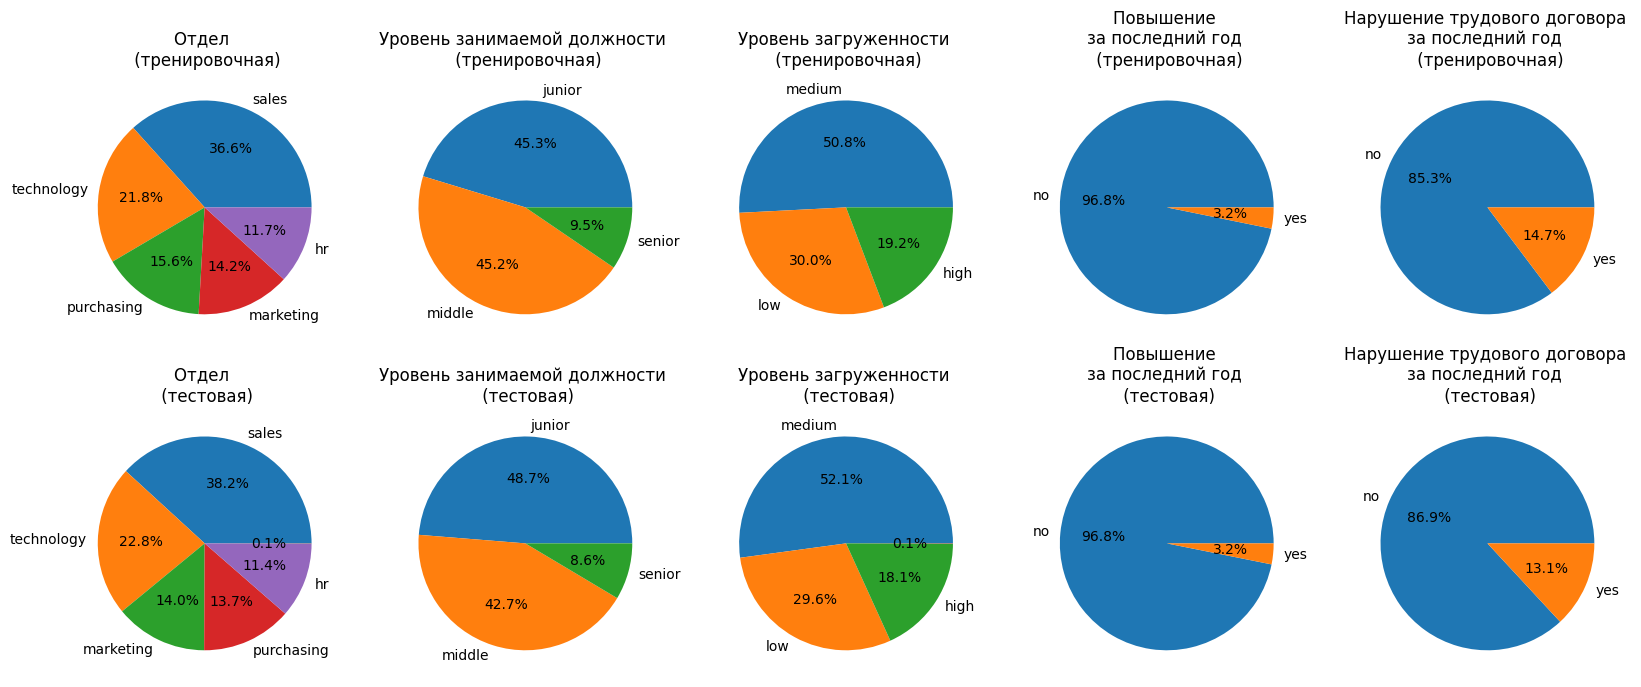

In [32]:
# построим круговые диаграммы
plt.figure(figsize=(20,8))

i = 1
for column in pie_col:
    plt.subplot(2, 5, i)
    pieplot(train_job_satisfaction_rate, column, f'{change_name(column)} \n (тренировочная)')

    plt.subplot(2, 5, i+5)
    pieplot(test, column, f'{change_name(column)} \n (тестовая)')

    i+=1;

**Вывод:**
1. Распределение работников по отделам практически равномерное, но работники Sales-блока преобладают (38%). 
2. Работников уровня junior и middle почти равное количество (~45%), а вот работников senior всего 8.9%.
3. В основном уровень загруженности работников средний (middle), у 30% - низкий (low) и ~18% - высокий. 
4. Из всех работников повышение было только у 3%. 
5. Из всех работников нарушение трудового договора было выявлено у 14%. 

Распределения признаков тестовой выборки не сильно отличаются от тренировочной. 

На графиках тестовой выборки можно заметить пропущенные значения, которые будут обработаны позднее. 

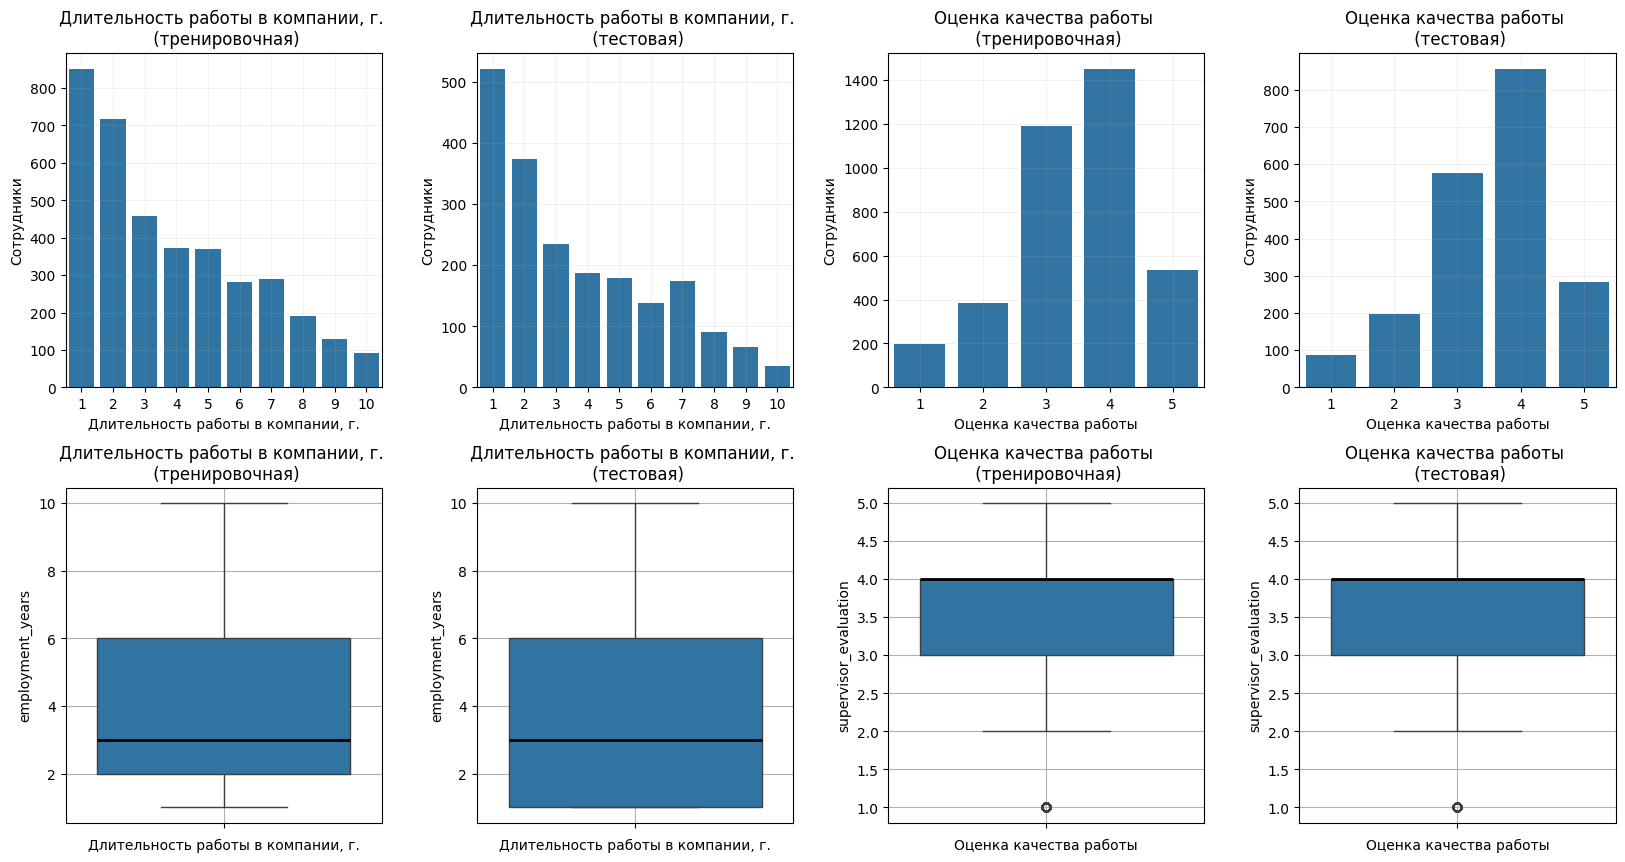

In [33]:
plt.figure(figsize=(20,10))

i = 1
for column in count_col:
    # построим столбчатую диаграмму
    plt.subplot(2, 4, i)
    countplot(train_job_satisfaction_rate, column, f'{change_name(column)} \n (тренировочная)', change_name(column), 'Сотрудники')

    # построим диаграмму размаха
    plt.subplot(2, 4, i+4)
    boxplot(train_job_satisfaction_rate, column, f'{change_name(column)} \n (тренировочная)', change_name(column))

    # построим столбчатую диаграмму
    plt.subplot(2, 4, i+1)
    countplot(test, column, f'{change_name(column)} \n (тестовая)', change_name(column), 'Сотрудники')

    # построим диаграмму размаха
    plt.subplot(2, 4, i+5)
    boxplot(test, column, f'{change_name(column)} \n (тестовая)', change_name(column))

    plt.subplots_adjust(hspace=0.3)
    plt.subplots_adjust(wspace=0.3)

    i+=2;

**Вывод:**

1. Основная масса работников - это те, кто работает в компании меньше 3 лет. Меньше всего работников, кто проработал 10 лет. 
2. Медианное значение оценки качества работы равно 4. Но есть и работники, которые получили 1 балл от своего руководителя. 

Распределения признаков тестовой выборки не сильно отличаются от тренировочной. 

#### Количественные признаки

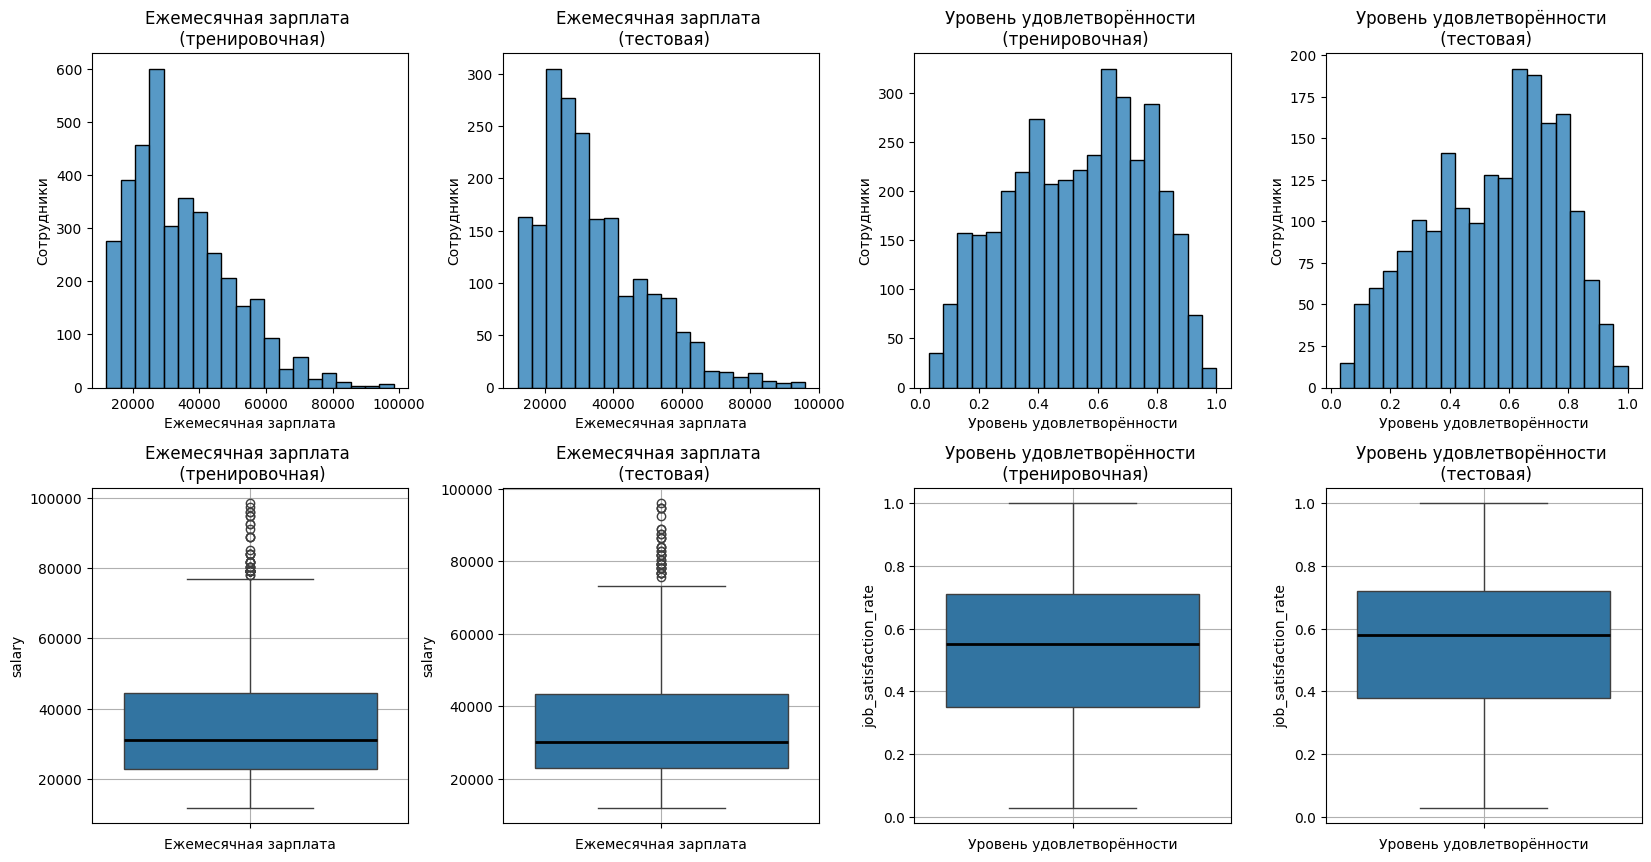

In [34]:
plt.figure(figsize=(20,10))
i = 1

for column in hist_col:
    # построим гистограмму
    plt.subplot(2, 4, i)
    hist(train_job_satisfaction_rate, column, f'{change_name(column)} \n (тренировочная)', change_name(column), 'Сотрудники')

    # построим диаграмму размаха
    plt.subplot(2, 4, i+4)
    boxplot(train_job_satisfaction_rate, column, f'{change_name(column)} \n (тренировочная)', change_name(column))

    # построим гистограмму
    plt.subplot(2, 4, i+1)
    hist(test, column, f'{change_name(column)} \n (тестовая)', change_name(column), 'Сотрудники')

    # построим диаграмму размаха
    plt.subplot(2, 4, i+5)
    boxplot(test, column, f'{change_name(column)} \n (тестовая)', change_name(column))

    plt.subplots_adjust(hspace=0.3)
    plt.subplots_adjust(wspace=0.3)
    
    i+=2;

In [35]:
# получим описание данных
df = pd.DataFrame()
for column in hist_col:
    df[f'{change_name(column)}, тренировочная'] = train_job_satisfaction_rate[column].describe()
    df[f'{change_name(column)}, тестовая'] = test[column].describe()
df

,"Ежемесячная зарплата, тренировочная","Ежемесячная зарплата, тестовая","Уровень удовлетворённости, тренировочная","Уровень удовлетворённости, тестовая"
count,3755.000000,2000.000000,3755.000000,2000.00000
mean,34457.416778,34066.800000,0.532554,0.54878
std,15050.643870,15398.436729,0.226393,0.22011
min,12000.000000,12000.000000,0.030000,0.03000
25%,22800.000000,22800.000000,0.350000,0.38000
50%,31200.000000,30000.000000,0.550000,0.58000
75%,44400.000000,43200.000000,0.710000,0.72000
max,98400.000000,96000.000000,1.000000,1.00000


**Вывод:**

1. Медианное значение зарплаты равно 30 000. Зарплату выше 70 000 можно считать выбросом. Распределение не похоже на нормальное.
2. Медианное значение уровня удовлетворенности равно 0.56. Распределение похоже на нормальное.

Распределения признаков тестовой выборки не сильно отличаются от тренировочной. 

#### Выводы по результатам исследовательского анализа данных

Были проанализированы признаки в тренировочных данных. 

Выбросов, требующих удаления, не обнаружено. 

Целевой признак (`уровень удовлетворенности`) распределен нормально, медианное значение равно 0.56. 

Распределения признаков тестовой выборки не сильно отличаются от тренировочной. 

### Корреляционный анализ

#### Коэффициенты корреляции

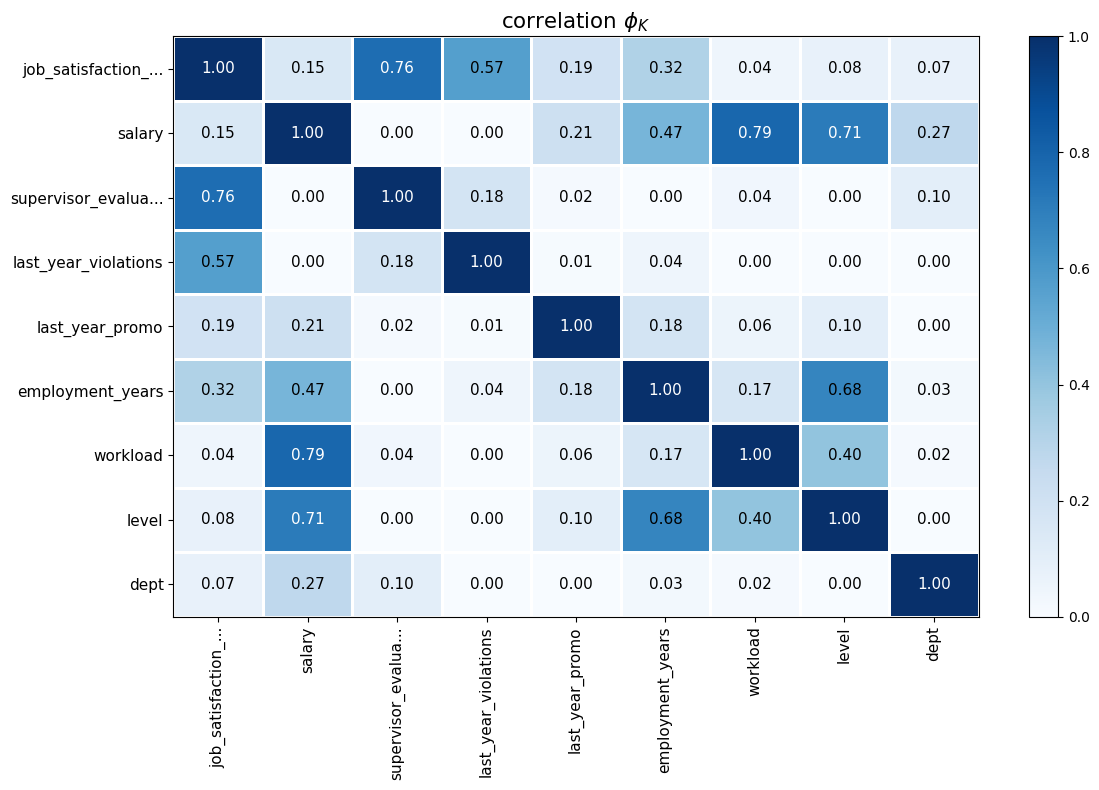

In [36]:
interval_cols = ['employment_years',
                 'salary',
                 'job_satisfaction_rate'
]

phik_overview = phik_matrix(train_job_satisfaction_rate, interval_cols=interval_cols)

plot_correlation_matrix(
    phik_overview.values,
    x_labels=phik_overview.columns,
    y_labels=phik_overview.index,
    vmin=0, vmax=1, color_map='Blues',
    title=r'correlation $\phi_K$',
    fontsize_factor=1.1,
    figsize=(12, 8)
);

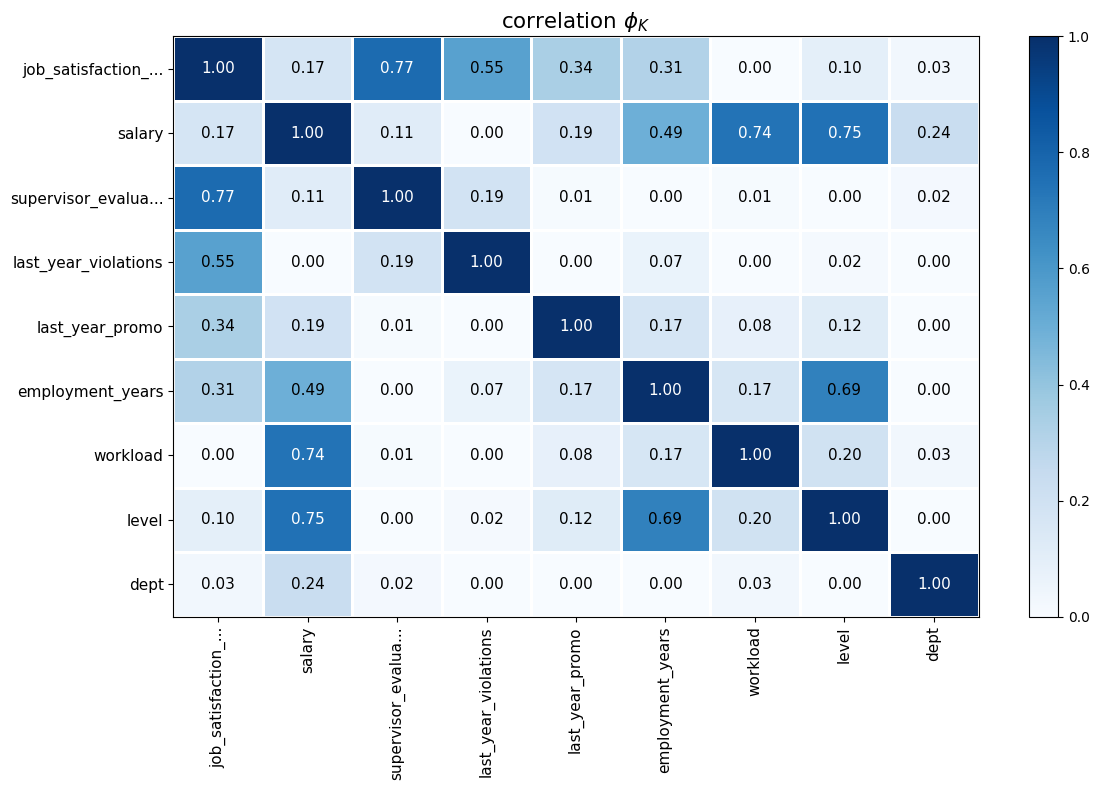

In [37]:
phik_overview = phik_matrix(test, interval_cols=interval_cols)

plot_correlation_matrix(
    phik_overview.values,
    x_labels=phik_overview.columns,
    y_labels=phik_overview.index,
    vmin=0, vmax=1, color_map='Blues',
    title=r'correlation $\phi_K$',
    fontsize_factor=1.1,
    figsize=(12, 8)
);

#### Проверка на мультиколлинеарность

In [38]:
# выполним проверку на мультиколлинеарность с использованием VIF
num_cols = [
    'employment_years',
    'supervisor_evaluation',
    'salary',
    'job_satisfaction_rate'
]

X = add_constant(train_job_satisfaction_rate[num_cols].drop('job_satisfaction_rate', axis=1))

vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

vif_data.sort_values(by='VIF', ascending=False)

,feature,VIF
0,const,17.827860
3,salary,1.255256
1,employment_years,1.255222
2,supervisor_evaluation,1.000031


#### Выводы по результатам корреляционного анализа

1. Выявлен высокий уровень корреляции между зарплатой (`salary`) и рабочей нагрузкой (`workload`) - 0.79.
2. Выявлен высокий уровень корреляции между зарплатой (`salary`) и уровнем занимаемой должности (`level`) - 0.72. 
3. Выявлен высокий уровень корреляции между оценкой от руководителя (`supervisor_evaluation`) и удовлетворенностью от работы (`job_satisfaction_rate`) - 0.76. 
4. Выявлен заметный уровень корреляции между нарушением трудового договора (`last_year_violations`) и удовлетворенностью от работы (`job_satisfaction_rate`) - 0.56. 
5. Выявлен заметный уровень корреляции между уровнем занимаемой должности (`level`) и количеством проработанных лет в компании (`employment_years`) - 0.68. 

Есть признаки, для которых отсутствует линейная зависимость с целевым признаком, что может повлиять на результаты обучения Линейной регрессии.

Уровни корреляции признаков тестовой выборки не сильно отличаются от тренировочной. 

Коэффициент инфляции дисперсии (VIF) ни для одного признака не превышает 5, что подтверждает отсутствие мультиколлинеарности.

### Обучение моделей

#### Подготовка данных и пайплайн

In [39]:
# разделим данные на входные и целевые
X_train = train_job_satisfaction_rate.drop(['job_satisfaction_rate'], axis=1).copy()
y_train = train_job_satisfaction_rate['job_satisfaction_rate'].copy()

X_test = test.drop(['job_satisfaction_rate'], axis=1).copy()
y_test = test['job_satisfaction_rate'].copy()

In [40]:
# разделим признаки на группы
ohe_columns = [
    'dept',
    'last_year_promo',
    'last_year_violations'
]

ord_columns = [
    'level',
    'workload'
]

num_columns = [
    'employment_years',
    'salary',
    'supervisor_evaluation'
]

In [41]:
# SimpleImputer + OHE
# здесь добавим обработку пропущенных значений, выявленных на этапе предобработки данных
try:
    ohe_pipe = Pipeline(
        [
            (
                'simpleImputer_ohe', 
                SimpleImputer(missing_values=np.nan, strategy='most_frequent')
            ),
            (
                'simpleImputer_bl', 
                SimpleImputer(missing_values=' ', strategy='most_frequent')
            ),
            (
                'ohe', 
                OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)
            )
        ]
    )
except:
    ohe_pipe = Pipeline(
    [
        (
            'simpleImputer_ohe', 
            SimpleImputer(missing_values=np.nan, strategy='most_frequent')
        ),
        (
                'simpleImputer_bl', 
                SimpleImputer(missing_values=' ', strategy='most_frequent')
            ),
        (
            'ohe', 
            OneHotEncoder(drop='first', handle_unknown='ignore', sparse=False)
        )
    ]
)

ohe_pipe

Pipeline(steps=[('simpleImputer_ohe', SimpleImputer(strategy='most_frequent')),
                ('simpleImputer_bl',
                 SimpleImputer(missing_values=' ', strategy='most_frequent')),
                ('ohe',
                 OneHotEncoder(drop='first', handle_unknown='ignore',
                               sparse_output=False))])

In [42]:
# SimpleImputer + ORD
# здесь добавим обработку пропущенных значений, выявленных на этапе предобработки данных
ord_pipe = Pipeline(
    [
        (
            'simpleImputer_before_ord', 
            SimpleImputer(missing_values=np.nan, strategy='most_frequent')
        ),
        (
                'simpleImputer_bl', 
                SimpleImputer(missing_values=' ', strategy='most_frequent')
            ),
        (
            'ord',  
            OrdinalEncoder(
                categories=[
                    ['junior', 'middle', 'senior'],
                    ['low', 'medium', 'high']
                ], 
                handle_unknown='use_encoded_value', unknown_value=np.nan
            )
        ),
        (
            'simpleImputer_after_ord', 
            SimpleImputer(missing_values=np.nan, strategy='most_frequent')
        )
    ]
)

ord_pipe

Pipeline(steps=[('simpleImputer_before_ord',
                 SimpleImputer(strategy='most_frequent')),
                ('simpleImputer_bl',
                 SimpleImputer(missing_values=' ', strategy='most_frequent')),
                ('ord',
                 OrdinalEncoder(categories=[['junior', 'middle', 'senior'],
                                            ['low', 'medium', 'high']],
                                handle_unknown='use_encoded_value',
                                unknown_value=nan)),
                ('simpleImputer_after_ord',
                 SimpleImputer(strategy='most_frequent'))])

In [43]:
data_preprocessor = ColumnTransformer(
    [
        ('ohe', ohe_pipe, ohe_columns),
        ('ord', ord_pipe, ord_columns),
        ('num', MinMaxScaler(), num_columns)
    ], 
    remainder='passthrough',
    force_int_remainder_cols=False
)

data_preprocessor

ColumnTransformer(force_int_remainder_cols=False, remainder='passthrough',
                  transformers=[('ohe',
                                 Pipeline(steps=[('simpleImputer_ohe',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('simpleImputer_bl',
                                                  SimpleImputer(missing_values=' ',
                                                                strategy='most_frequent')),
                                                 ('ohe',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['dept', 'last_yea...
                                                  SimpleImputer(missing_values=' ',
                                                                strategy='most_frequent')),
                                                 ('ord',
                                                  OrdinalEncoder(categories=[['junior',
                                                                              'middle',
                                                                              'senior'],
                                                                             ['low',
                                                                              'medium',
                                                                              'high']],
                                                                 handle_unknown='use_encoded_value',
                                                                 unknown_value=nan)),
                                                 ('simpleImputer_after_ord',
                                                  SimpleImputer(strategy='most_frequent'))]),
                                 ['level', 'workload']),
                                ('num', MinMaxScaler(),
                                 ['employment_years', 'salary',
                                  'supervisor_evaluation'])])

In [44]:
# итоговый пайплайн: подготовка данных и модель
pipe_final = Pipeline(
    [
        ('preprocessor', data_preprocessor),
        ('models', LinearRegression())
    ]
)

pipe_final

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(force_int_remainder_cols=False,
                                   remainder='passthrough',
                                   transformers=[('ohe',
                                                  Pipeline(steps=[('simpleImputer_ohe',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('simpleImputer_bl',
                                                                   SimpleImputer(missing_values=' ',
                                                                                 strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_ou...
                                                                                 strategy='most_frequent')),
                                                                  ('ord',
                                                                   OrdinalEncoder(categories=[['junior',
                                                                                               'middle',
                                                                                               'senior'],
                                                                                              ['low',
                                                                                               'medium',
                                                                                               'high']],
                                                                                  handle_unknown='use_encoded_value',
                                                                                  unknown_value=nan)),
                                                                  ('simpleImputer_after_ord',
                                                                   SimpleImputer(strategy='most_frequent'))]),
                                                  ['level', 'workload']),
                                                 ('num', MinMaxScaler(),
                                                  ['employment_years', 'salary',
                                                   'supervisor_evaluation'])])),
                ('models', LinearRegression())])

In [45]:
X_train_p = pd.DataFrame(
    data_preprocessor.fit_transform(X_train),
    columns=data_preprocessor.get_feature_names_out()
)

X_test_p = pd.DataFrame(
    data_preprocessor.transform(X_test),
    columns=data_preprocessor.get_feature_names_out() 
)

features_names=data_preprocessor.get_feature_names_out()

#### Создание метрики

 Создадим метрику **SMAPE** (англ.) - symmetric mean absolute percentage error, «симметричное среднее абсолютное процентное отклонение». 

 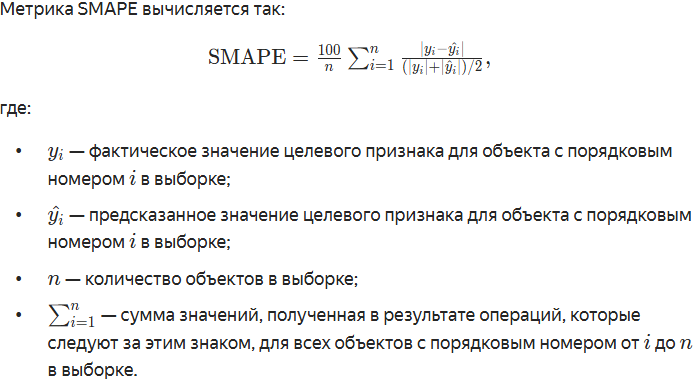

In [46]:
def smape_score(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    step1 = abs(y_true - y_pred)
    step2 = (abs(y_true) + abs(y_pred))/2
    step3 = 100/len(y_true)
    step4 = step1/step2
    step5 = step4.sum()
    step6 = step3 * step5
    return step6

smape = make_scorer(smape_score)

scoring = {"r2":'r2', "smape": make_scorer(smape_score)}

#### Линейная регрессия

In [47]:
%%time

param_grid_lr = [
    # словарь для модели LinearRegression() 
    {
        'models': [LinearRegression()],
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), RobustScaler(), 'passthrough']  
    }]

randomized_search = RandomizedSearchCV(
    pipe_final, 
    param_grid_lr, 
    cv=5,
    scoring=scoring,
    random_state=RANDOM_STATE,
    refit='smape', 
    n_jobs=-1, 
    verbose=3,
    n_iter=4
)

randomized_search.fit(X_train, y_train)
model_lr = randomized_search.best_estimator_

print('\nЛучшая модель и её параметры:\n')
model_lr

Fitting 5 folds for each of 4 candidates, totalling 20 fits

Лучшая модель и её параметры:

CPU times: total: 46.9 ms
Wall time: 378 ms


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(force_int_remainder_cols=False,
                                   remainder='passthrough',
                                   transformers=[('ohe',
                                                  Pipeline(steps=[('simpleImputer_ohe',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('simpleImputer_bl',
                                                                   SimpleImputer(missing_values=' ',
                                                                                 strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_ou...
                                                                                 strategy='most_frequent')),
                                                                  ('ord',
                                                                   OrdinalEncoder(categories=[['junior',
                                                                                               'middle',
                                                                                               'senior'],
                                                                                              ['low',
                                                                                               'medium',
                                                                                               'high']],
                                                                                  handle_unknown='use_encoded_value',
                                                                                  unknown_value=nan)),
                                                                  ('simpleImputer_after_ord',
                                                                   SimpleImputer(strategy='most_frequent'))]),
                                                  ['level', 'workload']),
                                                 ('num', StandardScaler(),
                                                  ['employment_years', 'salary',
                                                   'supervisor_evaluation'])])),
                ('models', LinearRegression())])

In [48]:
# посмотрим на результаты randomized_search
result = pd.DataFrame(randomized_search.cv_results_)
result[['mean_fit_time', 'param_preprocessor__num', 'param_models', 'params', 'mean_test_r2', 'mean_test_smape']].sort_values('mean_test_smape', ascending=True)

,mean_fit_time,param_preprocessor__num,param_models,params,mean_test_r2,mean_test_smape
3,0.017479,passthrough,LinearRegression(),"{'preprocessor__num': 'passthrough', 'models':...",0.688223,25.005621
2,0.018371,RobustScaler(),LinearRegression(),"{'preprocessor__num': RobustScaler(), 'models'...",0.688223,25.005621
1,0.017715,MinMaxScaler(),LinearRegression(),"{'preprocessor__num': MinMaxScaler(), 'models'...",0.688223,25.005621
0,0.017752,StandardScaler(),LinearRegression(),"{'preprocessor__num': StandardScaler(), 'model...",0.688223,25.005621


**Оценка работы модели**

In [49]:
print (f'Метрика модели при кросс валидации: {randomized_search.best_score_:.2f}', )

# обучение модели на тестовой выборке
y_pred_lr = model_lr.predict(X_test)

print(f'\nМетрика SMAPE на тестовой выборке: {smape_score(y_test, y_pred_lr):.2f}')
print(f'Метрика r2 на тестовой выборке: {r2_score(y_test, y_pred_lr):.2f}')

Метрика модели при кросс валидации: 25.01

Метрика SMAPE на тестовой выборке: 23.57
Метрика r2 на тестовой выборке: 0.68


**Анализ важности признаков**

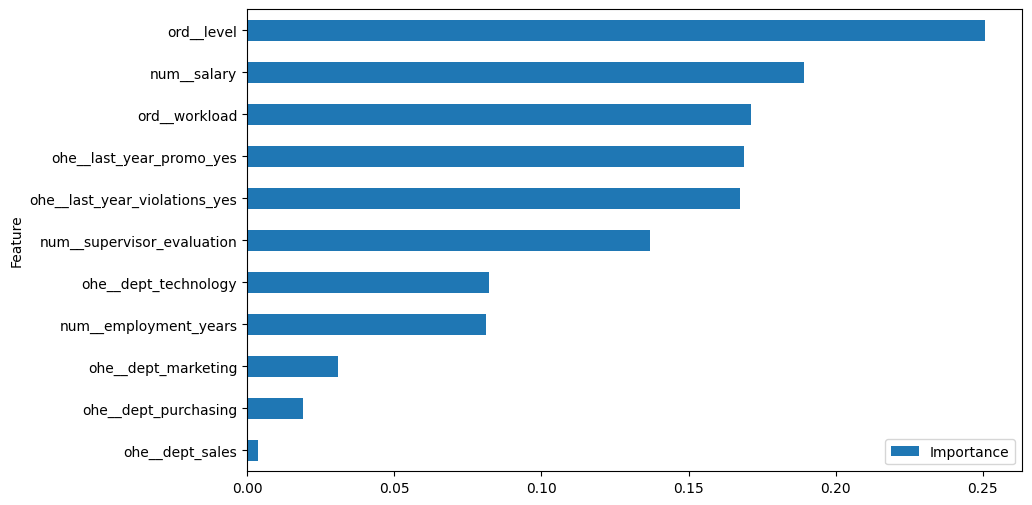

In [50]:
# проведем анализ важности признаков
coefficients = model_lr._final_estimator.coef_
feature_importance = pd.DataFrame({'Feature': X_test_p.columns, 'Importance': np.abs(coefficients)})
feature_importance = feature_importance.sort_values('Importance', ascending=True)
feature_importance.plot(x='Feature', y='Importance', kind='barh', figsize=(10, 6));

Наиболее важные признаки для модели:
- уровень занимаемой должности;
- уровень зарплаты;
- уровень загруженности. 

Наименее важные признаки относятся в названию отдела, в котором работает сотрудник. 

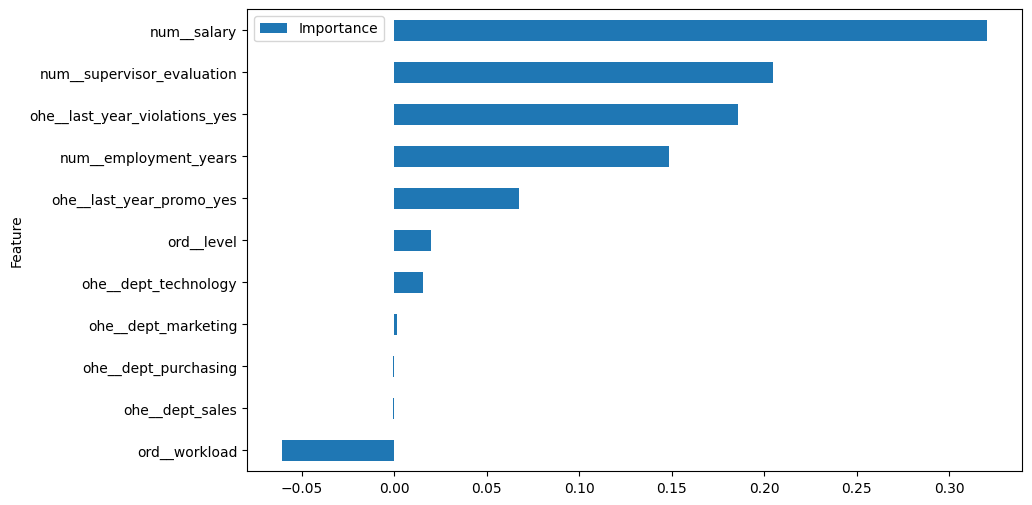

In [51]:
result = permutation_importance(model_lr._final_estimator, X_test_p.values, y_test, scoring='r2')

feature_importance = pd.DataFrame({'Feature': features_names, 'Importance': result['importances_mean']})
feature_importance = feature_importance.sort_values('Importance', ascending=True)
feature_importance.plot(x='Feature', y='Importance', kind='barh', figsize=(10, 6));

Перемешивание значений выявило следующие важный признаки: 
- уровень зарплаты;
- оценка руководителя;
- повышения за последний год. 

Принадлежность к отделам по прежнему не является важным признаком. 

#### Дерево решений

In [52]:
%%time

param_grid_tree = [    
    # словарь для модели DecisionTreeRegressor()
    {
        'models': [DecisionTreeRegressor(random_state=RANDOM_STATE)],
        'models__max_depth': range(2, 100),
        'models__max_features': range(2, 100),
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), RobustScaler(), 'passthrough']  
    }
]

randomized_search = RandomizedSearchCV(
    pipe_final, 
    param_grid_tree, 
    cv=5,
    scoring=scoring,
    random_state=RANDOM_STATE,
    refit='smape', 
    n_jobs=-1, 
    verbose=3,
    n_iter = 10
)

randomized_search.fit(X_train, y_train)
model_tree = randomized_search.best_estimator_

print('Лучшая модель и её параметры:\n\n')
model_tree

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Лучшая модель и её параметры:


CPU times: total: 125 ms
Wall time: 226 ms


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(force_int_remainder_cols=False,
                                   remainder='passthrough',
                                   transformers=[('ohe',
                                                  Pipeline(steps=[('simpleImputer_ohe',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('simpleImputer_bl',
                                                                   SimpleImputer(missing_values=' ',
                                                                                 strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_ou...
                                                                                               'middle',
                                                                                               'senior'],
                                                                                              ['low',
                                                                                               'medium',
                                                                                               'high']],
                                                                                  handle_unknown='use_encoded_value',
                                                                                  unknown_value=nan)),
                                                                  ('simpleImputer_after_ord',
                                                                   SimpleImputer(strategy='most_frequent'))]),
                                                  ['level', 'workload']),
                                                 ('num', StandardScaler(),
                                                  ['employment_years', 'salary',
                                                   'supervisor_evaluation'])])),
                ('models',
                 DecisionTreeRegressor(max_depth=4, max_features=21,
                                       random_state=42))])

In [53]:
# посмотрим на результаты randomized_search
result = pd.DataFrame(randomized_search.cv_results_)
result[['mean_fit_time', 'param_preprocessor__num', 'param_models', 'params', 'mean_test_r2', 'mean_test_smape']].sort_values('mean_test_smape', ascending=True).head()

,mean_fit_time,param_preprocessor__num,param_models,params,mean_test_r2,mean_test_smape
4,0.027951,MinMaxScaler(),DecisionTreeRegressor(random_state=42),"{'preprocessor__num': MinMaxScaler(), 'models_...",0.859726,15.958742
0,0.020712,passthrough,DecisionTreeRegressor(random_state=42),"{'preprocessor__num': 'passthrough', 'models__...",0.859130,15.971734
8,0.024529,passthrough,DecisionTreeRegressor(random_state=42),"{'preprocessor__num': 'passthrough', 'models__...",0.859130,15.971734
5,0.024338,RobustScaler(),DecisionTreeRegressor(random_state=42),"{'preprocessor__num': RobustScaler(), 'models_...",0.858101,16.000589
6,0.024133,RobustScaler(),DecisionTreeRegressor(random_state=42),"{'preprocessor__num': RobustScaler(), 'models_...",0.858101,16.000589


**Оценка работы модели**

In [54]:
print (f'Метрика модели при кросс валидации: {randomized_search.best_score_:.2f}')

# обучение модели на тестовой выборке
y_pred_tree = model_tree.predict(X_test)

print(f'\nМетрика SMAPE на тестовой выборке: {smape_score(y_test, y_pred_tree):.2f}')
print(f'Метрика r2 на тестовой выборке: {r2_score(y_test, y_pred_tree):.2f}')

Метрика модели при кросс валидации: 21.52

Метрика SMAPE на тестовой выборке: 20.40
Метрика r2 на тестовой выборке: 0.74


#### Анализ остатков

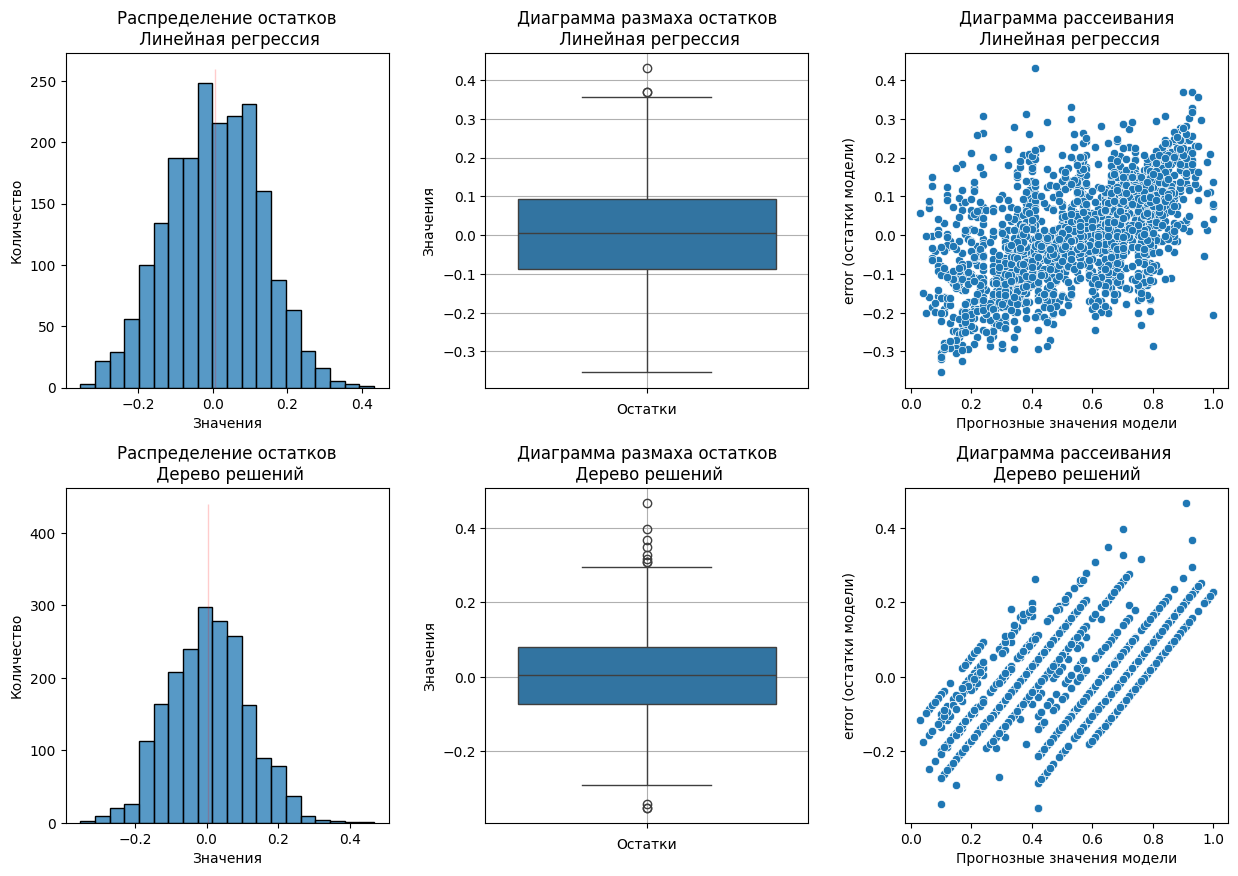

In [55]:
plt.figure(figsize=(15, 10))

# построим гистограмму распределения остатков
plt.subplot(2, 3, 1)
residuals_lr = y_test - y_pred_lr
sns.histplot(residuals_lr, bins=20)
sns.lineplot(x = residuals_lr.median(), y=[0, 260], color='red')
plt.title('Распределение остатков\n Линейная регрессия')
plt.xlabel('Значения')
plt.ylabel('Количество');

# построим диаграмму разамаха
plt.subplot(2, 3, 2)
sns.boxplot(residuals_lr)
plt.title('Диаграмма размаха остатков\n Линейная регрессия')
plt.grid()
plt.xlabel('Остатки')
plt.ylabel('Значения');

# построим диаграмму рассеивания остатков
plt.subplot(2, 3, 3)
sns.scatterplot(x=y_test, y=residuals_lr)
plt.title('Диаграмма рассеивания\n Линейная регрессия')
plt.xlabel('Прогнозные значения модели')
plt.ylabel('error (остатки модели)');

# построим гистограмму распределения остатков
plt.subplot(2, 3, 4)
residuals_tree = y_test - y_pred_tree
sns.histplot(residuals_tree, bins=20)
sns.lineplot(x = residuals_tree.median(), y=[0, 440], color='red')
plt.title('Распределение остатков\n Дерево решений')
plt.xlabel('Значения')
plt.ylabel('Количество');

# построим диаграмму разамаха
plt.subplot(2, 3, 5)
sns.boxplot(residuals_tree)
plt.title('Диаграмма размаха остатков\n Дерево решений')
plt.grid()
plt.xlabel('Остатки')
plt.ylabel('Значения');

# построим диаграмму рассеивания остатков
plt.subplot(2, 3, 6)
sns.scatterplot(x=y_test, y=residuals_tree)
plt.title('Диаграмма рассеивания \nДерево решений')
plt.xlabel('Прогнозные значения модели')
plt.ylabel('error (остатки модели)')

plt.subplots_adjust(hspace=0.3)
plt.subplots_adjust(wspace=0.3);

Для обоих моделей актуально:
- нормальное распределение остатков;
- среднее значение остатков близко к 0. 

Для дерева решений выявлено большее количество выбросов остатков, чем для линейной регрессии. 

Диаграмма рассеивания дерева решений более кучная, чем диаграмма линейной регрессии. 

#### Оценка качества модели

In [56]:
df = pd.DataFrame()

# посчитаем метрики для линейной регрессии
mae_lr = mean_absolute_error(y_test, y_pred_lr)
try:
    rmse_lr = mean_squared_error(y_test, y_pred_lr, squared=False) 
except:
    rmse_lr = root_mean_squared_error(y_test, y_pred_lr)

mse_lr = mean_squared_error(y_test, y_pred_lr)

# посчитаем метрики для дерева решений
mae_tree = mean_absolute_error(y_test, y_pred_tree)
try:
    rmse_tree = mean_squared_error(y_test, y_pred_tree, squared=False) 
except:
    rmse_tree = root_mean_squared_error(y_test, y_pred_tree)

mse_tree = mean_squared_error(y_test, y_pred_tree)

df['metrica'] = ['SMAPE', 'MAE', 'RMSE', 'MSE']
df['LinearRegression'] = [f'{smape_score(y_test, y_pred_lr):.2f}', f'{mae_lr:.4f}', f'{rmse_lr:.4f}', f'{mse_lr:.4f}']
df['DecisionTreeRegressor'] = [f'{smape_score(y_test, y_pred_tree):.2f}', f'{mae_tree:.4f}', f'{rmse_tree:.4f}', f'{mse_tree:.4f}']

df

,metrica,LinearRegression,DecisionTreeRegressor
0,SMAPE,23.57,20.40
1,MAE,0.1009,0.0897
2,RMSE,0.1238,0.1118
3,MSE,0.0153,0.0125


Значения метрик (в том числе созданной SMAPE) лучше для дерева решений. 
- **MAE** - значение средней абсолютной ошибки 0.06. 
- **RMSE** - значение квадратного корня из среднеквадратичной ошибки 0.08.
- **MSE** - значение среднеквадратичной ошибки 0.006. 

### Выводы задачи 1

Были обучены две модели: Линейная регрессия и Дерево решений. 

Была создана новая метрика для оценки моделей - SMAPE. 

Учитывая возможности по настройке гиперпараметров для модели Дерева решений, с помощью нее удалось добиться лучших результатов на тестовой выборке (SMAPE < 15). 

На этапе корреляционного анализа было выявлено, что есть признаки, для которых отсутствует линейная зависимость с целевым признаком, что повлияло на результат обучения Линейной регрессии.

Чтобы получить лучшие результаты для Линейной регрессии, можно было бы рассмотреть возможность добавления новых признаков, которые бы имели линейную зависимость с целевым признаком. 

## Задача 2. Предсказание увольнения сотрудника из компании

### Загрузка данных

In [57]:
# открываем файлы с данными 
try:
    test_features = pd.read_csv('datasets/test_features.csv')
    train_quit = pd.read_csv('datasets/train_quit.csv')
    test_target_quit = pd.read_csv('datasets/test_target_quit.csv')
except:
    test_features = pd.read_csv('/datasets/test_features.csv')
    train_quit = pd.read_csv('/datasets/train_quit.csv')
    test_target_quit = pd.read_csv('/datasets/test_target_quit.csv')

#### train_quit

In [58]:
# Выведем на экран 10 строк из набора данных
train_quit.head(10)

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,quit
0,723290,sales,middle,high,2,no,no,4,54000,no
1,814010,sales,junior,medium,2,no,no,4,27600,no
2,155091,purchasing,middle,medium,5,no,no,1,37200,no
3,257132,sales,junior,medium,2,no,yes,3,24000,yes
4,910140,marketing,junior,medium,2,no,no,5,25200,no
5,699916,sales,junior,low,1,no,yes,3,18000,yes
6,417070,technology,middle,medium,8,no,no,2,44400,no
7,165489,sales,middle,low,4,no,no,5,19200,no
8,996399,marketing,middle,low,7,no,no,4,25200,no
9,613206,technology,middle,medium,2,no,no,3,45600,yes


In [59]:
# Выведем основную информацию о датафрейме 
train_quit.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   id                     4000 non-null   int64 
 1   dept                   4000 non-null   object
 2   level                  4000 non-null   object
 3   workload               4000 non-null   object
 4   employment_years       4000 non-null   int64 
 5   last_year_promo        4000 non-null   object
 6   last_year_violations   4000 non-null   object
 7   supervisor_evaluation  4000 non-null   int64 
 8   salary                 4000 non-null   int64 
 9   quit                   4000 non-null   object
dtypes: int64(4), object(6)
memory usage: 312.6+ KB


#### test_target_quit

In [60]:
# Выведем на экран 10 строк из набора данных
test_target_quit.head(10)

,id,quit
0,999029,yes
1,372846,no
2,726767,no
3,490105,no
4,416898,yes
5,223063,no
6,810370,no
7,998900,no
8,578329,no
9,648850,no


In [61]:
# Выведем основную информацию о датафрейме 
test_target_quit.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      2000 non-null   int64 
 1   quit    2000 non-null   object
dtypes: int64(1), object(1)
memory usage: 31.4+ KB


In [62]:
# зададим id в качестве индексов датафреймов, чтобы по ним соединять таблицы в дальнейшем
# train_quit = train_quit.set_index('id') 
# test_target_quit = test_target_quit.set_index('id') 

#### Вывод по результатам загрузки данных

По результатам загрузки данных выявлено, что не требуется:
- переименование столбцов;
- изменение типов данных столбцов.

Однако, необходимо:
- проверить наличие пропусков; 
- проверить наличие дубликатов.

### Предобработка данных

In [63]:
# зададим id в качестве индексов датафреймов, чтобы по ним соединять таблицы в дальнейшем
train_quit = train_quit.set_index('id').rename_axis(index=None)
test_features = test_features.set_index('id').rename_axis(index=None)
test_target_quit = test_target_quit.set_index('id').rename_axis(index=None)

# для удобства анализа объединим тестовую признаки с таргетом
test_2 = test_features.join(test_target_quit)

#### Обработка пропусков

In [64]:
find_omissions(train_quit)

,Количество пропусков,"Доля пропусков, %"
dept,0,0.000000
level,0,0.000000
workload,0,0.000000
employment_years,0,0.000000
last_year_promo,0,0.000000
last_year_violations,0,0.000000
supervisor_evaluation,0,0.000000
salary,0,0.000000
quit,0,0.000000


In [65]:
find_omissions(test_2)

,Количество пропусков,"Доля пропусков, %"
dept,2,0.100000
level,1,0.050000
workload,0,0.000000
employment_years,0,0.000000
last_year_promo,0,0.000000
last_year_violations,0,0.000000
supervisor_evaluation,0,0.000000
salary,0,0.000000
quit,0,0.000000


**Вывод:**

Выявлены пропуски в таблице `test_features`. 

На этапе разработки пайплайна потребуется добавить шаг для обработки пропусков. 

#### Поиск дубликатов

In [66]:
find_duplicate(train_quit)

dept ['sales' 'purchasing' 'marketing' 'technology' 'hr'] 

level ['middle' 'junior' 'sinior'] 

workload ['high' 'medium' 'low'] 

last_year_promo ['no' 'yes'] 

last_year_violations ['no' 'yes'] 

quit ['no' 'yes'] 



In [67]:
# исправим опечатку в sinior
train_quit.loc[train_quit['level'] == 'sinior', 'level'] = 'senior'

In [68]:
find_duplicate(test_2)

dept ['marketing' 'hr' 'sales' 'purchasing' 'technology' nan ' '] 

level ['junior' 'middle' 'sinior' nan] 

workload ['medium' 'low' 'high' ' '] 

last_year_promo ['no' 'yes'] 

last_year_violations ['no' 'yes'] 

quit ['no' 'yes'] 



In [69]:
# проверим количество явных дубликатов
train_quit.duplicated().sum()

np.int64(1413)

In [70]:
# удалим полные дубликаты
train_quit.drop_duplicates(inplace=True, ignore_index=False)

# проверим результат
train_quit.duplicated().sum()

np.int64(0)

In [71]:
# проверим количество явных дубликатов
test_features.duplicated().sum()

np.int64(557)

In [72]:
# проверим количество явных дубликатов
test_target_quit.duplicated().sum()

np.int64(1998)

**Вывод:**

Выявили в некоторых ячейках пустые строки. Добавим их обработку в пайплайн.

Выявили дубликаты. Т.к. дубликаты на тренировочной выборке могут повлиять на обучение модели, удалили их. 

Из других таблиц было принято решение дубликаты не удалять.

#### Вывод по результатам предобработки данных

На анализ получены данные достаточно хорошего качества. 

Были выявлены: небольшое количество пропусков и пустые значения в некоторых ячейках.

Для обработки всех пропущенных значений будем использовать пайплайн (настроим замену на наиболее часто встречаемые значения с помощью SimpleImputer).

Дубликаты в тренировочных данных были удалены.

### Исследовательский анализ данных

#### Анализ признаков

In [73]:
# разделим названия колонок на группы в зависимости от графика, с помощью которого лучше визуализировать данные
pie_col = ['dept', 'level', 'workload', 'last_year_promo', 'last_year_violations']
count_col = ['employment_years', 'supervisor_evaluation']
hist_col = ['salary']

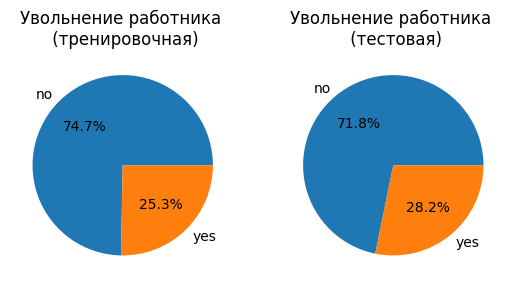

In [74]:
plt.subplot(1, 2, 1)
pieplot(train_quit, 'quit', f'{change_name("quit")} \n (тренировочная)')

plt.subplot(1, 2, 2)
pieplot(test_2, 'quit', f'{change_name("quit")} \n (тестовая)')

Выявлен дисбаланс классов, нужно будет выполнять сэмплирование данных.

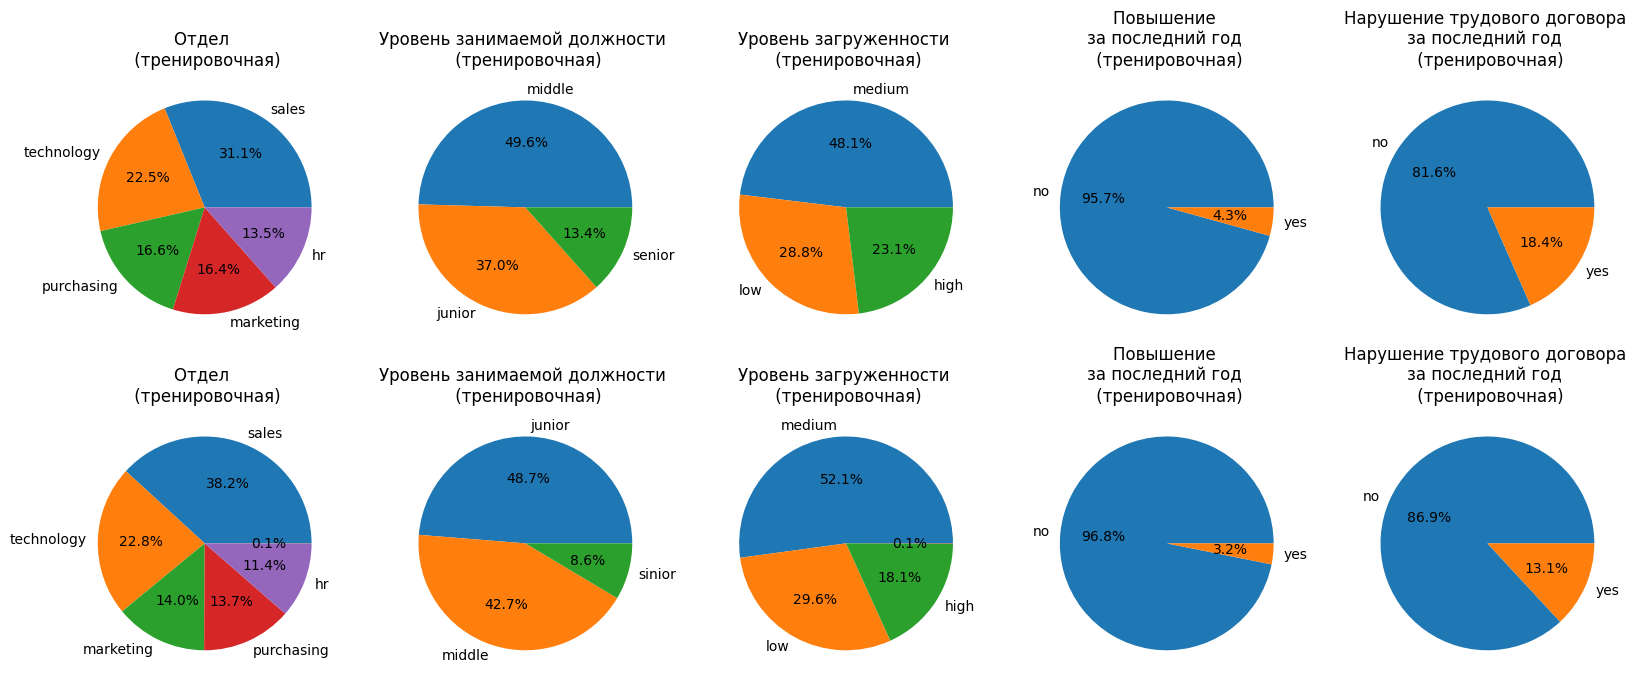

In [75]:
# построим круговые диаграммы
plt.figure(figsize=(20,8))

i = 1
for column in pie_col:
    plt.subplot(2, 5, i)
    pieplot(train_quit, column, f'{change_name(column)} \n (тренировочная)')

    plt.subplot(2, 5, i+5)
    pieplot(test_2, column, f'{change_name(column)} \n (тренировочная)')

    i+=1;

Распределения признаков тестовой выборки не сильно отличаются от тренировочной. 

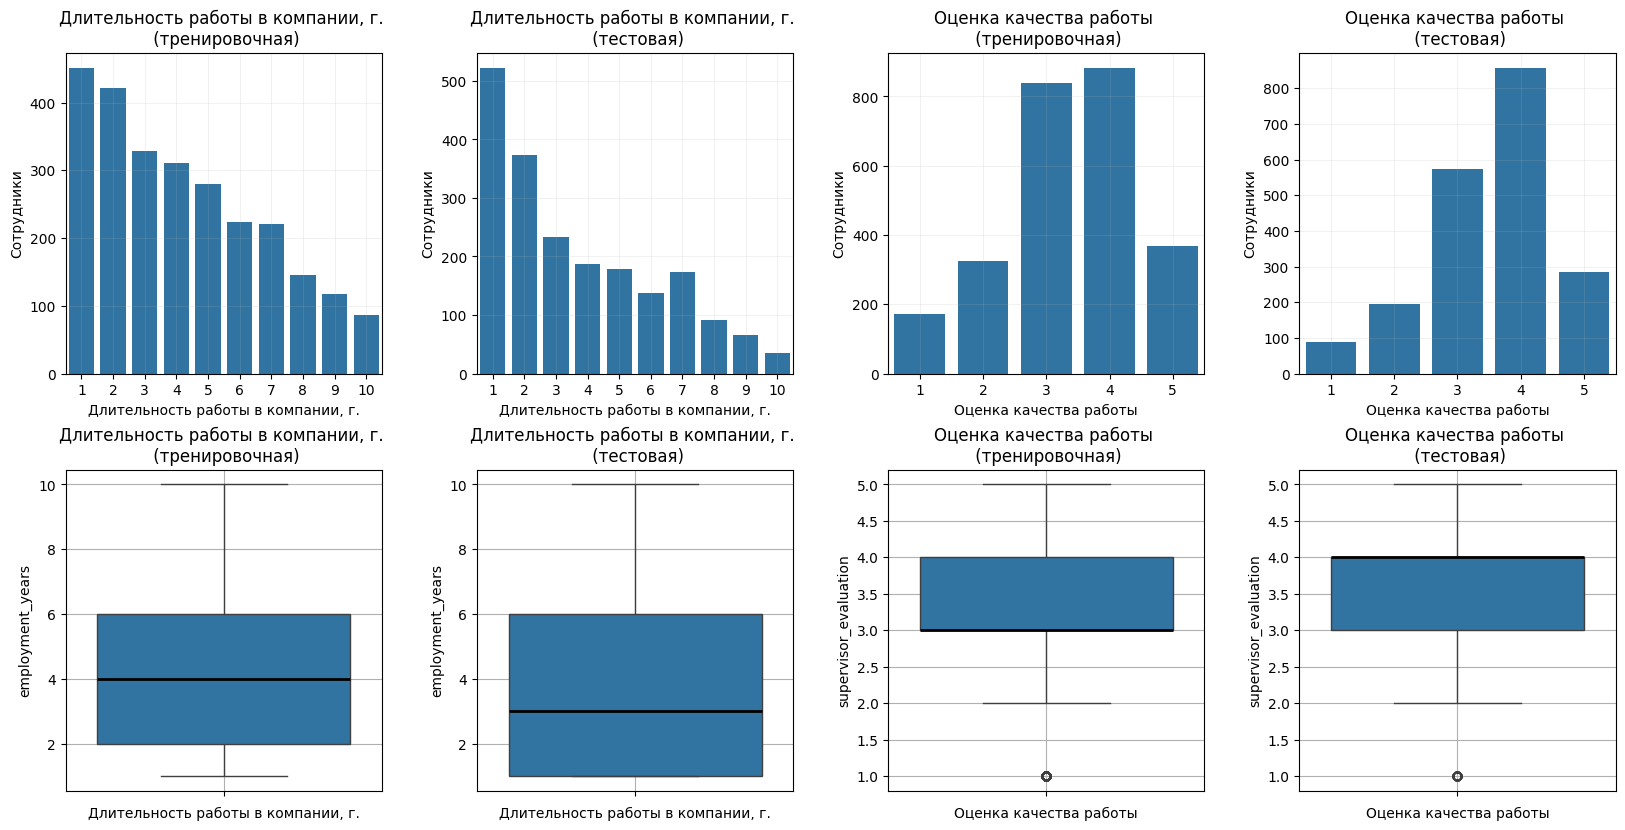

In [76]:
plt.figure(figsize=(20,15))

i = 1
for column in count_col:
    # построим столбчатую диаграмму
    plt.subplot(3, 4, i)
    countplot(train_quit, column, f'{change_name(column)} \n (тренировочная)', change_name(column), 'Сотрудники')

    # построим диаграмму размаха
    plt.subplot(3, 4, i+4)
    boxplot(train_quit, column, f'{change_name(column)} \n (тренировочная)', change_name(column))

    # построим столбчатую диаграмму
    plt.subplot(3, 4, i+1)
    countplot(test_2, column, f'{change_name(column)} \n (тестовая)', change_name(column), 'Сотрудники')

    # построим диаграмму размаха
    plt.subplot(3, 4, i+5)
    boxplot(test_2, column, f'{change_name(column)} \n (тестовая)', change_name(column))

    plt.subplots_adjust(hspace=0.3)
    plt.subplots_adjust(wspace=0.3)

    i+=2;

Распределения признаков тестовой выборки не сильно отличаются от тренировочной. 

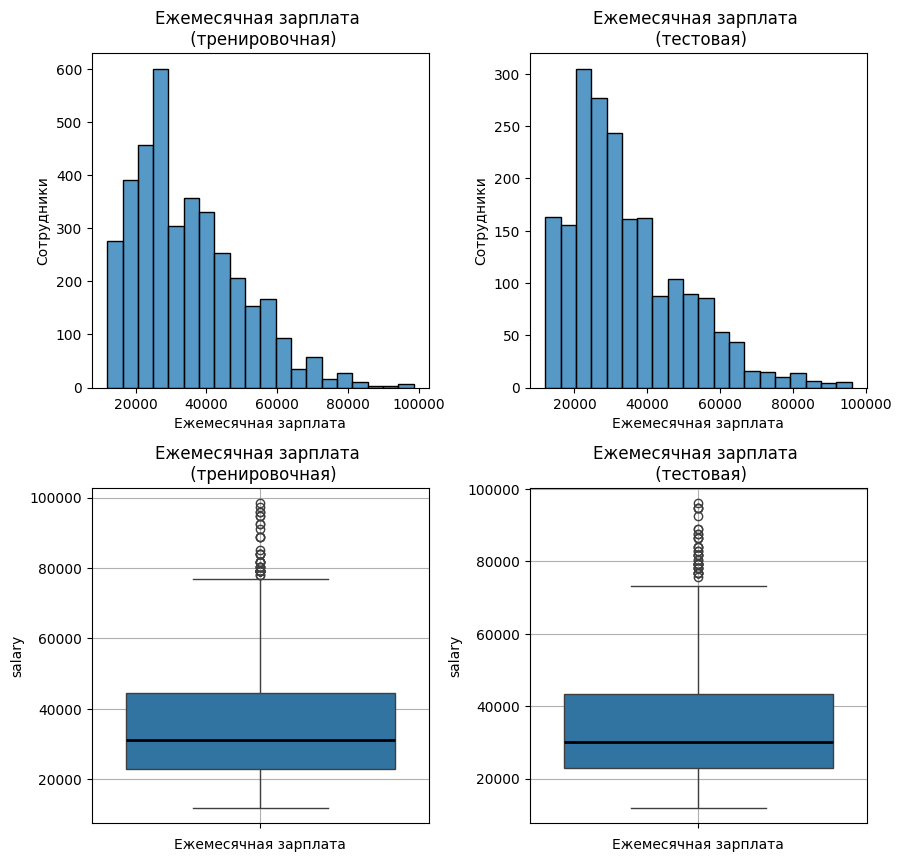

In [77]:
plt.figure(figsize=(10,10))
i = 1

for column in hist_col:
    # построим гистограмму
    plt.subplot(2, 2, i)
    hist(train_job_satisfaction_rate, column, f'{change_name(column)} \n (тренировочная)', change_name(column), 'Сотрудники')

    # построим диаграмму размаха
    plt.subplot(2, 2, i+2)
    boxplot(train_job_satisfaction_rate, column, f'{change_name(column)} \n (тренировочная)', change_name(column))

    # построим гистограмму
    plt.subplot(2, 2, i+1)
    hist(test_2, column, f'{change_name(column)} \n (тестовая)', change_name(column), 'Сотрудники')

    # построим диаграмму размаха
    plt.subplot(2, 2, i+3)
    boxplot(test_2, column, f'{change_name(column)} \n (тестовая)', change_name(column))

    plt.subplots_adjust(hspace=0.3)
    plt.subplots_adjust(wspace=0.3)
    
    i+=2;

Распределения признаков тестовой выборки не сильно отличаются от тренировочной. 

**Выводы:**

Были проанализированы признаки в тренировочных данных, произведено сравнение с тестовыми данными. 

Выбросов, требующих удаления, не обнаружено. 

Целевой признак (`увольнение сотрудника из компании`) имеет дисбаланс, который нужно будет учесть при создании пайплайна. 

Распределения признаков тестовой выборки не сильно отличаются от тренировочной. 

#### Портрет уволившегося сотрудника

In [78]:
# разделим тренировочную выборку на две
quit = train_quit[train_quit['quit']=='yes']
work = train_quit[train_quit['quit']=='no']

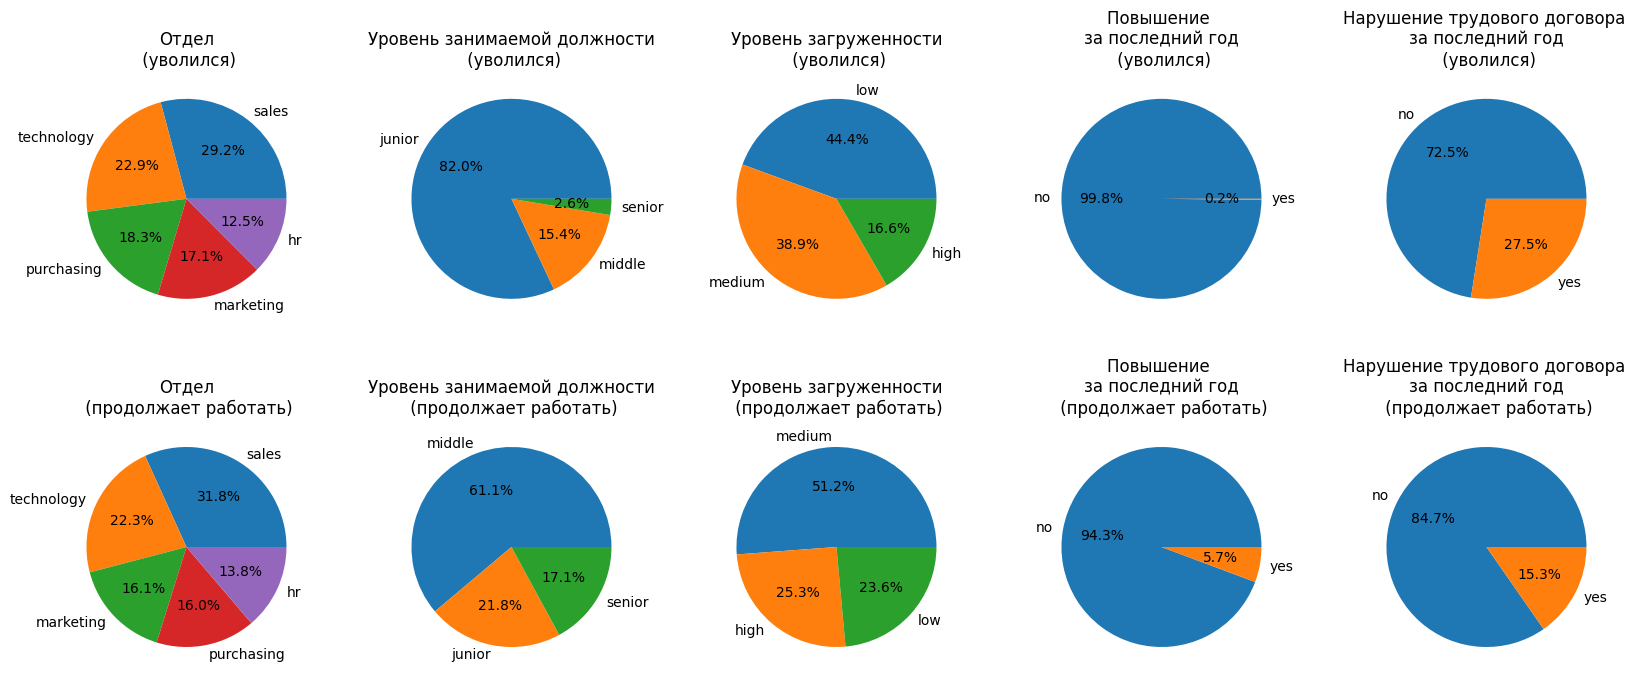

In [79]:
# построим круговые диаграммы
plt.figure(figsize=(20,8))

i = 1
for column in pie_col:
    plt.subplot(2, 5, i)
    pieplot(quit, column, f'{change_name(column)}\n (уволился)')

    plt.subplot(2, 5, i+5)
    pieplot(work, column, f'{change_name(column)}\n (продолжает работать)')

    plt.subplots_adjust(hspace=0.3)
    plt.subplots_adjust(wspace=0.3)

    i+=1;

В сравнении с работниками, которые остались в компании, можно выделить признаки, характерные уволвшимся сотрудникам: 
- чаще увольняются работники с уровнем занимаемой должности junior;
- чаще увольняются работники с низким (low) уровнем загруженности;
- почти все уволившиейся сотрудники не получали повышение за последний год;
- уволившиеся сотрудники нарушали трудовой договор чаще тех, кто остался работать.

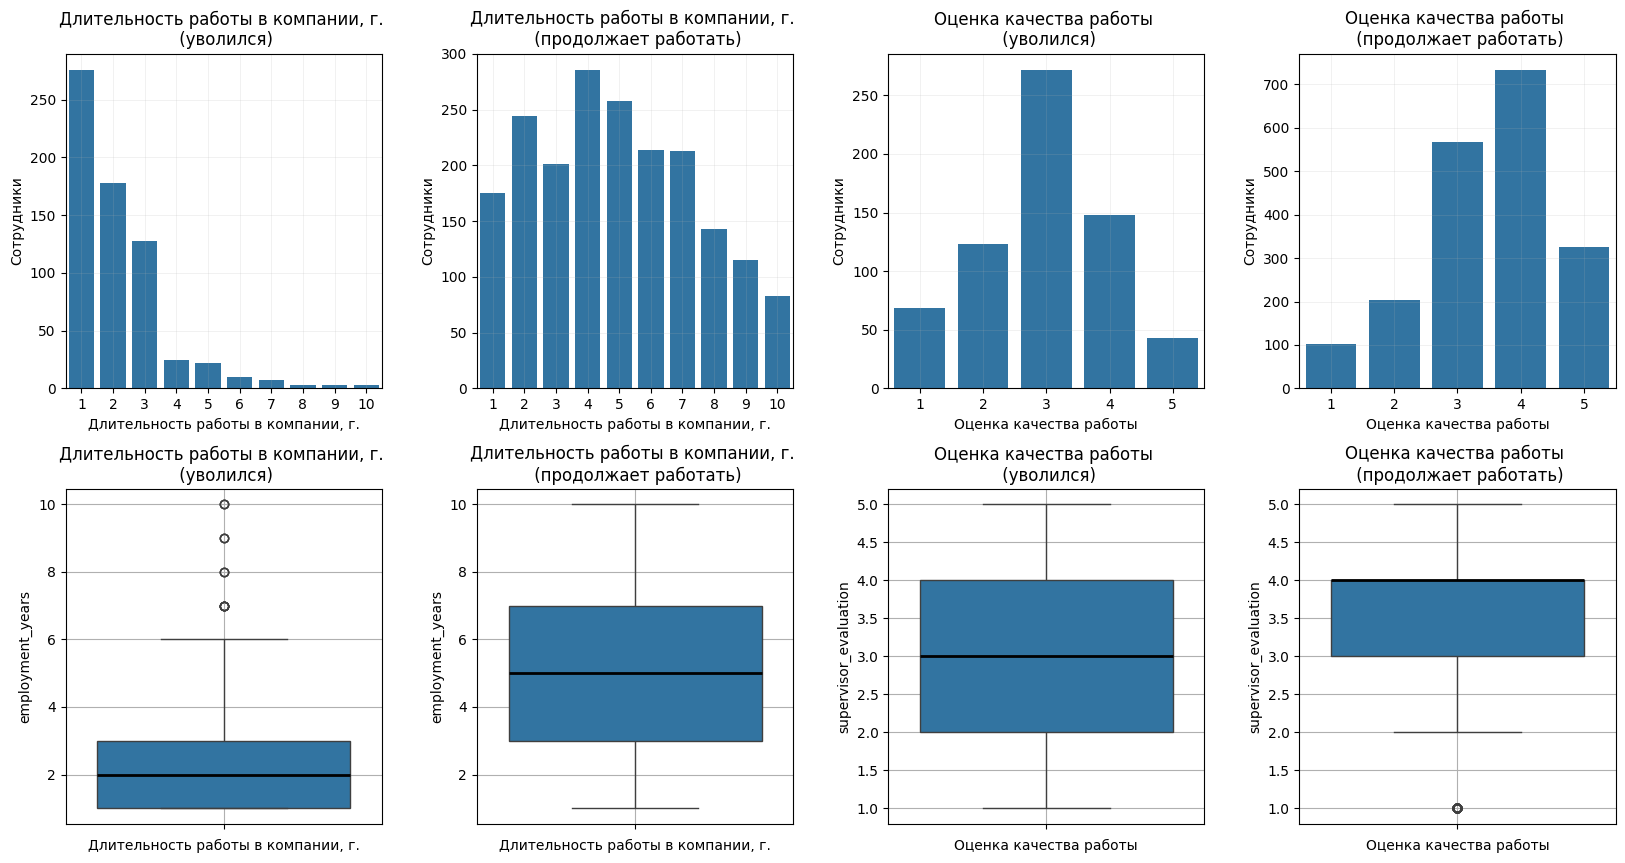

In [80]:
plt.figure(figsize=(20,10))

i = 1
for column in count_col:
    # построим столбчатую диаграмму
    plt.subplot(2, 4, i)
    countplot(quit, column, f'{change_name(column)} \n (уволился)', change_name(column), 'Сотрудники')

    # построим диаграмму размаха
    plt.subplot(2, 4, i+4)
    boxplot(quit, column, f'{change_name(column)} \n (уволился)', change_name(column))

    # построим столбчатую диаграмму
    plt.subplot(2, 4, i+1)
    countplot(work, column, f'{change_name(column)} \n (продолжает работать)', change_name(column), 'Сотрудники')    

    # построим диаграмму размаха
    plt.subplot(2, 4, i+5)
    boxplot(work, column, f'{change_name(column)} \n (продолжает работать)', change_name(column))

    plt.subplots_adjust(hspace=0.3)
    plt.subplots_adjust(wspace=0.3)
    
    i+=2;

В основном уволившиеся работники работают в компании не больше 3 лет, в то время как медианное значение оставшихся в компании работников ~4.5 года. 

Медианная оценка качества работы уволившихся работников - 3, в то время как медианное значение оставшихся в компании работников - 4. 

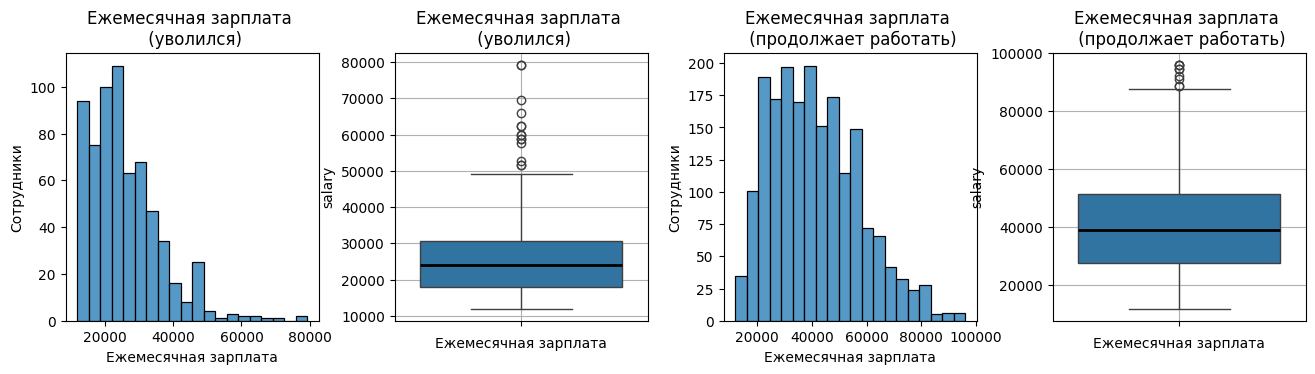

In [81]:
plt.figure(figsize=(16,8))
i = 1

for column in hist_col:
    # построим гистограмму 
    plt.subplot(2, 4, i)
    hist(quit, column, f'{change_name(column)} \n (уволился)', change_name(column), 'Сотрудники')
    
    # построим диаграмму размаха
    plt.subplot(2, 4, i+1)
    boxplot(quit, column, f'{change_name(column)} \n (уволился)', change_name(column))

    # построим гистограмму
    plt.subplot(2, 4, i+2)
    hist(work, column, f'{change_name(column)} \n (продолжает работать)', change_name(column), 'Сотрудники')

    # построим диаграмму размаха
    plt.subplot(2, 4, i+3)
    boxplot(work, column, f'{change_name(column)} \n (продолжает работать)', change_name(column))

    plt.subplots_adjust(hspace=0.3)
    plt.subplots_adjust(wspace=0.3)


In [82]:
# получим описание данных
df = pd.DataFrame()
for column in hist_col:
    df[f'{change_name(column)}, уволился'] = quit[column].describe()
    df[f'{change_name(column)}, продолжает работать'] = work[column].describe()
df

,"Ежемесячная зарплата, уволился","Ежемесячная зарплата, продолжает работать"
count,655.000000,1932.000000
mean,25767.938931,40952.173913
std,10484.828614,16085.739667
min,12000.000000,12000.000000
25%,18000.000000,27600.000000
50%,24000.000000,39000.000000
75%,30600.000000,51600.000000
max,79200.000000,96000.000000


Медианные и средние зарплаты уволившихся сотрудников почти в 2 раза меньше, чем у тех, кто продолжает работать. 

Уровень максимальной зарплаты у уволившихся работников ниже, чем у тех, кто продолжает работать. 

**Вывод:**

Уволившийся сотрудник, вероятно, будет обладать следующими характеристиками:

1. Уровень занимаемой должности - junior.
2. Уровень загруженности - низкий (low).
3. Без повышения за последний год. 
4. Возможно, нарушивший трудовой договор. 
5. Работает в компании менее 4 лет. 
6. Оценка качества работы от руководителя - 3.
7. Ежемесячная зарплата ~ 24 000.

#### Зависимость удовлетворенности сотрудника и увольнения

In [83]:
# объединим тестовые выборки из задачи 1 и задачи 2
test_full = pd.concat([test_target_job_satisfaction_rate, test_target_quit], axis=1)

# проверим, что объединение прошло корректно
test_full[(~test_full['quit'].isna()) & (test_full['job_satisfaction_rate'].isna())].head()

,job_satisfaction_rate,quit


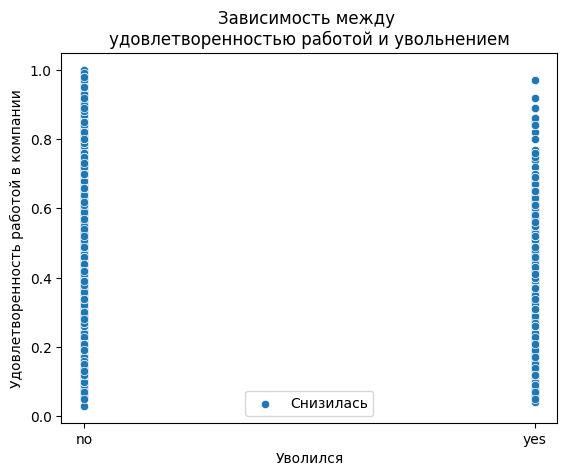

In [84]:
# построим диаграмму зависимостей
sns.scatterplot(data=test_full, y='job_satisfaction_rate', x='quit');

# plt.title(f'Зависимость разниц между выручками по месяцам\n'.upper())

plt.title(f'Зависимость между \nудовлетворенностью работой и увольнением')
plt.legend(labels=['Снизилась', 'Прежний уровень'])
plt.ylabel(f'Удовлетворенность работой в компании')
plt.xlabel('Уволился');

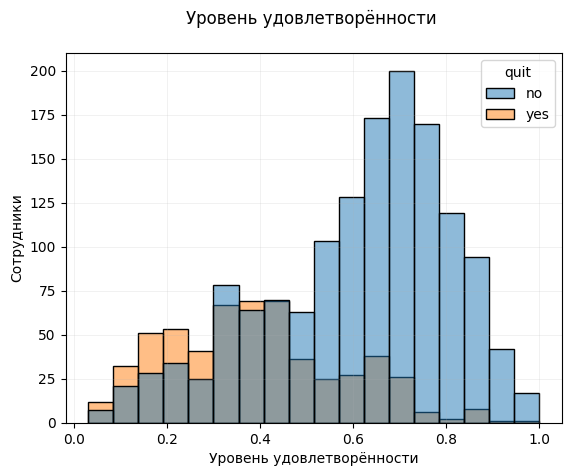

In [85]:
sns.histplot(data=test_full, x = 'job_satisfaction_rate', hue='quit')
plt.title(f'{change_name("job_satisfaction_rate")} \n')
plt.grid(linewidth=0.4, alpha=0.3)
plt.xlabel(change_name('job_satisfaction_rate'))
plt.ylabel('Сотрудники');

In [86]:
# заменим значения и проверим уровень корреляции
test_full.loc[test_full['quit'] == 'yes', 'quit'] = 1
test_full.loc[test_full['quit'] == 'no', 'quit'] = 0
test_full['quit'] = test_full['quit'].astype('int64')

test_full['job_satisfaction_rate'].corr(test_full['quit'])

np.float64(-0.4587109953195685)

**Вывод:**

Прослеживается умеренный уровень корреляции между признаками `job_satisfaction_rate` и `quit`. 

#### Вывод по результатам исследовательского анализа данных

Был составлен портрет уволившегося работника:
1. Уровень занимаемой должности - junior.
2. Уровень загруженности - низкий (low).
3. Без повышения за последний год. 
4. Возможно, нарушивший трудовой договор. 
5. Работает в компании менее 4 лет. 
6. Оценка качества работы от руководителя - 3.
7. Ежемесячная зарплата ~ 24 000.

Был выявлен умеренный уровень корреляции между признаками `job_satisfaction_rate` и `quit`. 

Чем ниже уровень удовлетворенности работой в компании у сотрудника, тем выше шанс того, что он уволится. 

### Добавление нового входного признака

In [87]:
# добавим в качестве нового признака результаты расчетов уровня удовлетворенности сотрудников
train_quit['job_satisfaction_rate'] = model_tree.predict(train_quit.drop('quit', axis=1))
test_2['job_satisfaction_rate'] = model_tree.predict(X_test)

In [88]:
# проверим результаты добавления
train_quit.head()

,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,quit,job_satisfaction_rate
723290,sales,middle,high,2,no,no,4,54000,no,0.706610
814010,sales,junior,medium,2,no,no,4,27600,no,0.706610
155091,purchasing,middle,medium,5,no,no,1,37200,no,0.442443
257132,sales,junior,medium,2,no,yes,3,24000,yes,0.216452
910140,marketing,junior,medium,2,no,no,5,25200,no,0.706610


In [89]:
# проверим результаты добавления
test_2.head()

,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,quit,job_satisfaction_rate
485046,marketing,junior,medium,2,no,no,5,28800,no,0.706610
686555,hr,junior,medium,1,no,no,4,30000,no,0.634840
467458,sales,middle,low,5,no,no,4,19200,no,0.772707
418655,sales,middle,low,6,no,no,4,19200,no,0.772707
789145,hr,middle,medium,5,no,no,5,40800,no,0.772707


### Корреляционный анализ

#### Коэффициенты корреляции

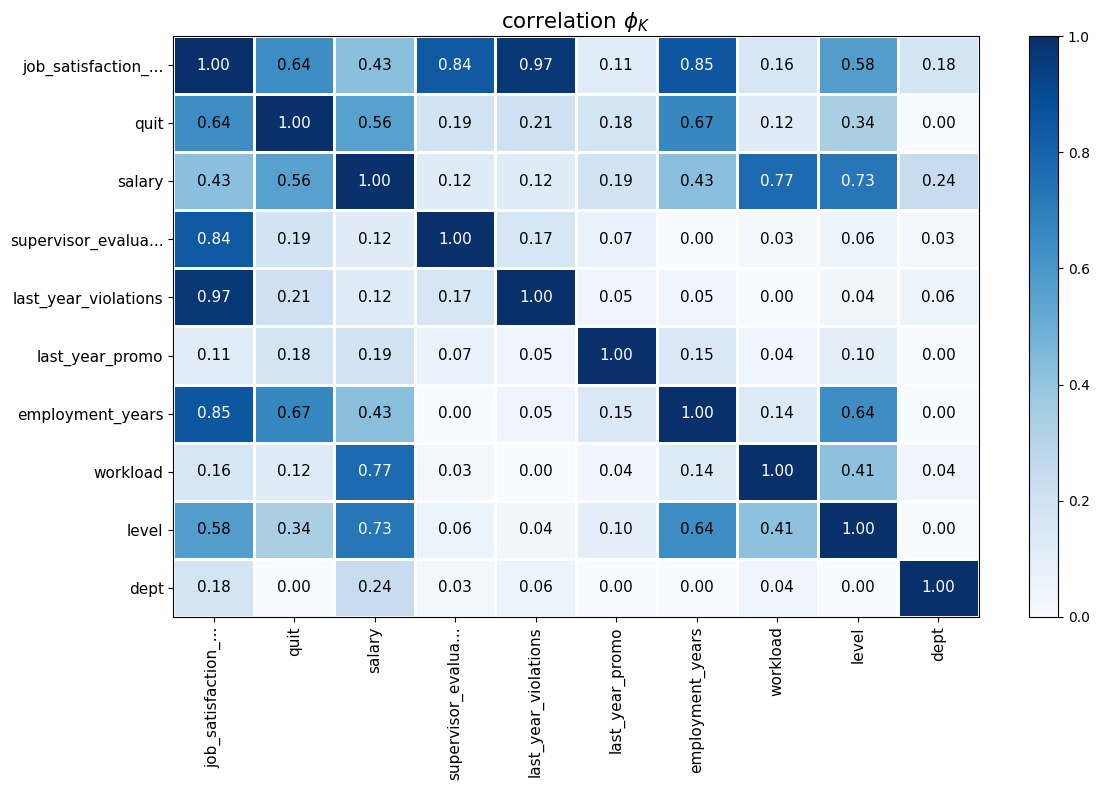

In [90]:
interval_cols = ['employment_years',
                 'salary',
                 'job_satisfaction_rate'
]

phik_overview = phik_matrix(train_quit, interval_cols=interval_cols)

plot_correlation_matrix(
    phik_overview.values,
    x_labels=phik_overview.columns,
    y_labels=phik_overview.index,
    vmin=0, vmax=1, color_map='Blues',
    title=r'correlation $\phi_K$',
    fontsize_factor=1.1,
    figsize=(12, 8)
);

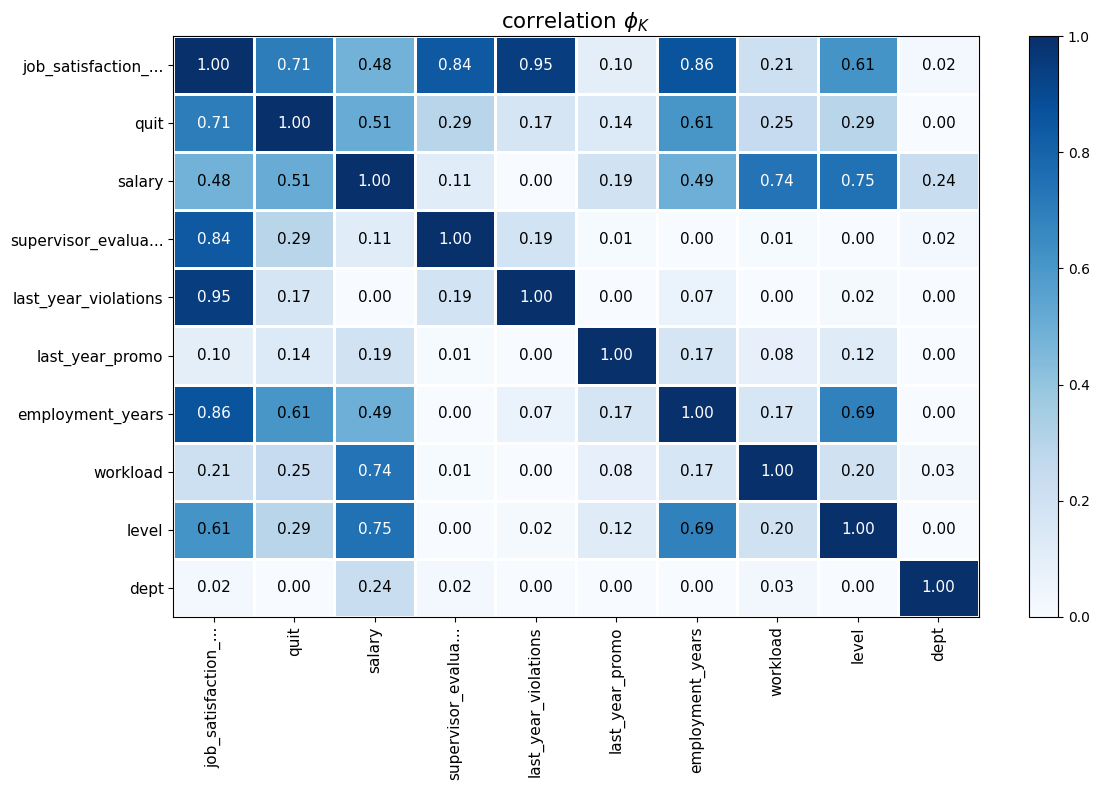

In [91]:
phik_overview = phik_matrix(test_2, interval_cols=interval_cols)

plot_correlation_matrix(
    phik_overview.values,
    x_labels=phik_overview.columns,
    y_labels=phik_overview.index,
    vmin=0, vmax=1, color_map='Blues',
    title=r'correlation $\phi_K$',
    fontsize_factor=1.1,
    figsize=(12, 8)
);

#### Выводы по результатам корреляционного анализа

1. Выявлен высокий уровень корреляции между уровнем зарплаты (`salary`) и рабочей нагрузкой (`workload`) - 0.77.
2. Выявлен высокий уровень корреляции между зарплатой (`salary`) и уровнем занимаемой должности (`level`) - 0.73. 
3. Выявлен высокий уровень корреляции между оценкой от руководителя (`supervisor_evaluation`) и удовлетворенностью от работы (`job_satisfaction_rate`) - 0.76. 
4. Выявлен заметный уровень корреляции между нарушением трудового договора (`last_year_violations`) и удовлетворенностью от работы (`job_satisfaction_rate`) - 0.60. 
5. Выявлен заметный уровень корреляции между уровнем занимаемой должности (`level`) и количеством проработанных лет в компании (`employment_years`) - 0.64. 
6. Выявлен заметный уровень корреляции между увольнением (`quit`) и количеством проработанных лет в компании (`employment_years`) - 0.67.
7. Выявлен заметный уровень корреляции между увольнением (`quit`) и уровнем зарплаты (`salary`) - 0.56.

Уровни корреляции признаков тестовой выборки не сильно отличаются от тренировочной. 

### Обучение модели

#### Подготовка данных и пайплайн

In [92]:
# заменим строковые значения целевого признака на 0 и 1
train_quit.loc[train_quit['quit'] == 'yes', 'quit'] = 1
train_quit.loc[train_quit['quit'] == 'no', 'quit'] = 0
train_quit['quit'] = train_quit['quit'].astype('int64')

train_quit['quit'].value_counts()

quit
0    1932
1     655
Name: count, dtype: int64

In [93]:
test_2.loc[test_2['quit'] == 'yes', 'quit'] = 1
test_2.loc[test_2['quit'] == 'no', 'quit'] = 0
test_2['quit'] = test_2['quit'].astype('int64')

In [94]:
# разделим данные на входные и целевые
X_train = train_quit.drop(['quit'], axis=1).copy()
y_train = train_quit['quit'].copy()

X_test = test_2.drop(['quit'], axis=1).copy()
y_test = test_2['quit'].copy()

In [95]:
# для сэмплирования данных посчитаем веса
# class_weights = compute_class_weight('balanced', classes=np.unique(train_quit['quit']), y=train_quit['quit'])

In [96]:
# разделим признаки на группы
ohe_columns = [
    'dept',
    'last_year_promo',
    'last_year_violations'
]

ord_columns = [
    'level',
    'workload'
]

num_columns = [
    'employment_years',
    'salary',
    'supervisor_evaluation',
    'job_satisfaction_rate'
]

In [97]:
# SimpleImputer + OHE
# здесь добавим обработку пропущенных значений, выявленных на этапе предобработки данных
try:
    ohe_pipe = Pipeline(
        [
            (
                'simpleImputer_ohe', 
                SimpleImputer(missing_values=np.nan, strategy='most_frequent')
            ),
            (
                'simpleImputer_bl', 
                SimpleImputer(missing_values=' ', strategy='most_frequent')
            ),
            (
                'ohe', 
                OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)
            )
        ]
    )
except:
    ohe_pipe = Pipeline(
    [
        (
            'simpleImputer_ohe', 
            SimpleImputer(missing_values=np.nan, strategy='most_frequent')
        ),
        (
                'simpleImputer_bl', 
                SimpleImputer(missing_values=' ', strategy='most_frequent')
            ),
        (
            'ohe', 
            OneHotEncoder(drop='first', handle_unknown='ignore', sparse=False)
        )
    ]
)

ohe_pipe

Pipeline(steps=[('simpleImputer_ohe', SimpleImputer(strategy='most_frequent')),
                ('simpleImputer_bl',
                 SimpleImputer(missing_values=' ', strategy='most_frequent')),
                ('ohe',
                 OneHotEncoder(drop='first', handle_unknown='ignore',
                               sparse_output=False))])

In [98]:
# SimpleImputer + ORD
# здесь добавим обработку пропущенных значений, выявленных на этапе предобработки данных
ord_pipe = Pipeline(
    [
        (
            'simpleImputer_before_ord', 
            SimpleImputer(missing_values=np.nan, strategy='most_frequent')
        ),
        (
                'simpleImputer_bl', 
                SimpleImputer(missing_values=' ', strategy='most_frequent')
            ),
        (
            'ord',  
            OrdinalEncoder(
                categories=[
                    ['junior', 'middle', 'senior'],
                    ['low', 'medium', 'high']
                ], 
                handle_unknown='use_encoded_value', unknown_value=np.nan
            )
        ),
        (
            'simpleImputer_after_ord', 
            SimpleImputer(missing_values=np.nan, strategy='most_frequent')
        )
    ]
)

ord_pipe

Pipeline(steps=[('simpleImputer_before_ord',
                 SimpleImputer(strategy='most_frequent')),
                ('simpleImputer_bl',
                 SimpleImputer(missing_values=' ', strategy='most_frequent')),
                ('ord',
                 OrdinalEncoder(categories=[['junior', 'middle', 'senior'],
                                            ['low', 'medium', 'high']],
                                handle_unknown='use_encoded_value',
                                unknown_value=nan)),
                ('simpleImputer_after_ord',
                 SimpleImputer(strategy='most_frequent'))])

In [99]:
data_preprocessor = ColumnTransformer(
    [
        ('ohe', ohe_pipe, ohe_columns),
        ('ord', ord_pipe, ord_columns),
        ('num', MinMaxScaler(), num_columns)
    ], 
    remainder='passthrough',
    force_int_remainder_cols=False
)

data_preprocessor

ColumnTransformer(force_int_remainder_cols=False, remainder='passthrough',
                  transformers=[('ohe',
                                 Pipeline(steps=[('simpleImputer_ohe',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('simpleImputer_bl',
                                                  SimpleImputer(missing_values=' ',
                                                                strategy='most_frequent')),
                                                 ('ohe',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['dept', 'last_yea...
                                                                strategy='most_frequent')),
                                                 ('ord',
                                                  OrdinalEncoder(categories=[['junior',
                                                                              'middle',
                                                                              'senior'],
                                                                             ['low',
                                                                              'medium',
                                                                              'high']],
                                                                 handle_unknown='use_encoded_value',
                                                                 unknown_value=nan)),
                                                 ('simpleImputer_after_ord',
                                                  SimpleImputer(strategy='most_frequent'))]),
                                 ['level', 'workload']),
                                ('num', MinMaxScaler(),
                                 ['employment_years', 'salary',
                                  'supervisor_evaluation',
                                  'job_satisfaction_rate'])])

In [100]:
# итоговый пайплайн: подготовка данных и модель
pipe_final = Pipeline(
    [
        ('preprocessor', data_preprocessor),
        ('models', LinearRegression())
    ]
)

pipe_final

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(force_int_remainder_cols=False,
                                   remainder='passthrough',
                                   transformers=[('ohe',
                                                  Pipeline(steps=[('simpleImputer_ohe',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('simpleImputer_bl',
                                                                   SimpleImputer(missing_values=' ',
                                                                                 strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_ou...
                                                                   OrdinalEncoder(categories=[['junior',
                                                                                               'middle',
                                                                                               'senior'],
                                                                                              ['low',
                                                                                               'medium',
                                                                                               'high']],
                                                                                  handle_unknown='use_encoded_value',
                                                                                  unknown_value=nan)),
                                                                  ('simpleImputer_after_ord',
                                                                   SimpleImputer(strategy='most_frequent'))]),
                                                  ['level', 'workload']),
                                                 ('num', MinMaxScaler(),
                                                  ['employment_years', 'salary',
                                                   'supervisor_evaluation',
                                                   'job_satisfaction_rate'])])),
                ('models', LinearRegression())])

In [101]:
X_train_p = pd.DataFrame(
    data_preprocessor.fit_transform(X_train),
    columns=data_preprocessor.get_feature_names_out() 
)

X_test_p = pd.DataFrame(
    data_preprocessor.transform(X_test),
    columns=data_preprocessor.get_feature_names_out() 
)

features_names=data_preprocessor.get_feature_names_out()

#### Модели (попытка №1)

In [102]:
param_grid = [
    # словарь для модели LogisticRegression()
    {
        'models': [LogisticRegression(
            random_state=RANDOM_STATE, 
            solver='liblinear', 
            penalty='l1',
#             class_weight=dict(enumerate(class_weights))
        )],
        'models__C': range(1, 10),
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), RobustScaler(), 'passthrough']  
    },
    # словарь для модели KNeighborsClassifier() 
    {
        'models': [KNeighborsClassifier()],
        'models__n_neighbors': range(2, 7),
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), RobustScaler(), 'passthrough']  
    },
    # словарь для модели DecisionTreeClassifier()
    {
        'models': [DecisionTreeClassifier(
            random_state=RANDOM_STATE,
#             class_weight=dict(enumerate(class_weights))
            )],
        'models__max_depth': range(2, 7),
        'models__max_features': range(2, 7),
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), RobustScaler(), 'passthrough']  
    },    
    
    # словарь для модели SVC()
    {
        'models': [SVC(
            kernel='poly',
            random_state=RANDOM_STATE,
            probability=True,
#             class_weight=dict(enumerate(class_weights))
        )],
        'models__degree': range(2, 7),
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), RobustScaler(), 'passthrough']  
    }
]

In [103]:
%%time


randomized_search = RandomizedSearchCV(
    pipe_final, 
    param_grid, 
    cv=5,
    scoring='roc_auc',
    random_state=RANDOM_STATE,
    n_jobs=-1, 
    verbose=3
)
randomized_search.fit(X_train, y_train)

model = randomized_search.best_estimator_

print('Лучшая модель и её параметры:\n\n')
randomized_search.best_estimator_

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Лучшая модель и её параметры:


CPU times: total: 78.1 ms
Wall time: 613 ms


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(force_int_remainder_cols=False,
                                   remainder='passthrough',
                                   transformers=[('ohe',
                                                  Pipeline(steps=[('simpleImputer_ohe',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('simpleImputer_bl',
                                                                   SimpleImputer(missing_values=' ',
                                                                                 strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_ou...
                                                                                               'medium',
                                                                                               'high']],
                                                                                  handle_unknown='use_encoded_value',
                                                                                  unknown_value=nan)),
                                                                  ('simpleImputer_after_ord',
                                                                   SimpleImputer(strategy='most_frequent'))]),
                                                  ['level', 'workload']),
                                                 ('num', RobustScaler(),
                                                  ['employment_years', 'salary',
                                                   'supervisor_evaluation',
                                                   'job_satisfaction_rate'])])),
                ('models',
                 LogisticRegression(C=8, penalty='l1', random_state=42,
                                    solver='liblinear'))])

In [104]:
print ('Метрика лучшей модели на тренировочной выборке:', randomized_search.best_score_)

Метрика лучшей модели на тренировочной выборке: 0.9031809352222269


In [105]:
# рассчитаем прогноз на тестовых данных
y_test_pred = randomized_search.predict(X_test)

# получим предсказания вероятностей на тестовых данных
preds = model.predict_proba(X_test)

In [106]:
# посчитаем метрику ROC-AUC
roc = roc_auc_score(y_test, preds[:,1])
print('Метрика ROC-AUC на тестовой выборке =', round(roc,2))

Метрика ROC-AUC на тестовой выборке = 0.9


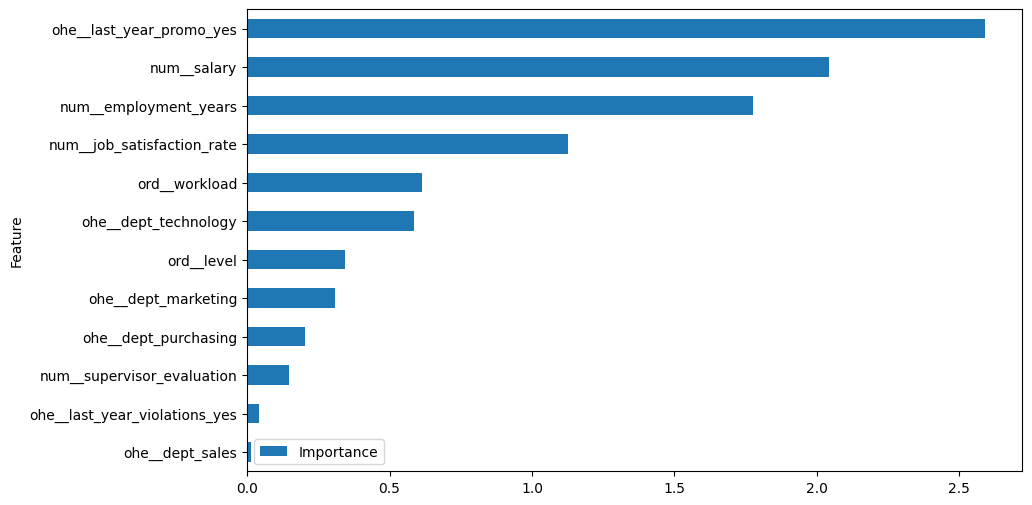

In [107]:
# проведем анализ важности признаков
coefficients = model._final_estimator.coef_[0]
feature_importance = pd.DataFrame({'Feature': X_test_p.columns, 'Importance': np.abs(coefficients)})
feature_importance = feature_importance.sort_values('Importance', ascending=True)
feature_importance.plot(x='Feature', y='Importance', kind='barh', figsize=(10, 6));

In [108]:
# формируем таблицу важности признаков
feature_importances = pd.DataFrame({'Feature': X_test_p.columns, 'Importance': np.abs(coefficients)})

# формируем список признаков с важностью менее 0.2
features_to_drop = feature_importances[
    feature_importances['Importance'] < 0.2
]['Feature']

features_to_drop

2                   ohe__dept_sales
5     ohe__last_year_violations_yes
10       num__supervisor_evaluation
Name: Feature, dtype: object

**Вывод:**

При первой попытке был получен результат метрики ROC-AUC - 0.9. 

По результатам корреляционного анализа данных было выявлено, что отсутствует корреляция между таргетом и признаком `dept`. 

По результатам анализа важности признаков было выявлено, что один из наименее важных признаков - `dept`.

Попробуем удалить этот признак, а также внести небольшие изменения в перечни для подбора гиперпараметров модели и проверим результат. 

#### Модели (попытка №2)

In [109]:
# разделим данные на входные и целевые
X_train_2 = train_quit.drop(['quit', 'dept'], axis=1).copy()
y_train_2 = train_quit['quit'].copy()

X_test_2 = test_2.drop(['quit', 'dept'], axis=1).copy()
y_test_2 = test_2['quit'].copy()

In [110]:
# для сэмплирования данных посчитаем веса
# class_weights = compute_class_weight('balanced', classes=np.unique(train_quit['quit'].copy()), y=train_quit['quit'].copy())

In [111]:
# разделим признаки на группы
ohe_columns = [
    'last_year_promo',
    'last_year_violations'
]

ord_columns = [
    'level',
    'workload'
]

num_columns = [
    'employment_years',
    'salary',
    'supervisor_evaluation',
    'job_satisfaction_rate'
]

In [112]:
# SimpleImputer + OHE
# здесь добавим обработку пропущенных значений, выявленных на этапе предобработки данных
try:
    ohe_pipe = Pipeline(
        [
            (
                'simpleImputer_ohe', 
                SimpleImputer(missing_values=np.nan, strategy='most_frequent')
            ),
            (
                'simpleImputer_bl', 
                SimpleImputer(missing_values=' ', strategy='most_frequent')
            ),
            (
                'ohe', 
                OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)
            )
        ]
    )
except:
    ohe_pipe = Pipeline(
    [
        (
            'simpleImputer_ohe', 
            SimpleImputer(missing_values=np.nan, strategy='most_frequent')
        ),
        (
                'simpleImputer_bl', 
                SimpleImputer(missing_values=' ', strategy='most_frequent')
            ),
        (
            'ohe', 
            OneHotEncoder(drop='first', handle_unknown='ignore', sparse=False)
        )
    ]
)

ohe_pipe

Pipeline(steps=[('simpleImputer_ohe', SimpleImputer(strategy='most_frequent')),
                ('simpleImputer_bl',
                 SimpleImputer(missing_values=' ', strategy='most_frequent')),
                ('ohe',
                 OneHotEncoder(drop='first', handle_unknown='ignore',
                               sparse_output=False))])

In [113]:
# SimpleImputer + ORD
# здесь добавим обработку пропущенных значений, выявленных на этапе предобработки данных
ord_pipe = Pipeline(
    [
        (
            'simpleImputer_before_ord', 
            SimpleImputer(missing_values=np.nan, strategy='most_frequent')
        ),
        (
                'simpleImputer_bl', 
                SimpleImputer(missing_values=' ', strategy='most_frequent')
            ),
        (
            'ord',  
            OrdinalEncoder(
                categories=[
                    ['junior', 'middle', 'senior'],
                    ['low', 'medium', 'high']
                ], 
                handle_unknown='use_encoded_value', unknown_value=np.nan
            )
        ),
        (
            'simpleImputer_after_ord', 
            SimpleImputer(missing_values=np.nan, strategy='most_frequent')
        )
    ]
)

ord_pipe

Pipeline(steps=[('simpleImputer_before_ord',
                 SimpleImputer(strategy='most_frequent')),
                ('simpleImputer_bl',
                 SimpleImputer(missing_values=' ', strategy='most_frequent')),
                ('ord',
                 OrdinalEncoder(categories=[['junior', 'middle', 'senior'],
                                            ['low', 'medium', 'high']],
                                handle_unknown='use_encoded_value',
                                unknown_value=nan)),
                ('simpleImputer_after_ord',
                 SimpleImputer(strategy='most_frequent'))])

In [114]:
data_preprocessor = ColumnTransformer(
    [
        ('ohe', ohe_pipe, ohe_columns),
        ('ord', ord_pipe, ord_columns),
        ('num', MinMaxScaler(), num_columns)
    ], 
    remainder='passthrough',
    force_int_remainder_cols=False
)

data_preprocessor

ColumnTransformer(force_int_remainder_cols=False, remainder='passthrough',
                  transformers=[('ohe',
                                 Pipeline(steps=[('simpleImputer_ohe',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('simpleImputer_bl',
                                                  SimpleImputer(missing_values=' ',
                                                                strategy='most_frequent')),
                                                 ('ohe',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['last_year_promo...
                                                                strategy='most_frequent')),
                                                 ('ord',
                                                  OrdinalEncoder(categories=[['junior',
                                                                              'middle',
                                                                              'senior'],
                                                                             ['low',
                                                                              'medium',
                                                                              'high']],
                                                                 handle_unknown='use_encoded_value',
                                                                 unknown_value=nan)),
                                                 ('simpleImputer_after_ord',
                                                  SimpleImputer(strategy='most_frequent'))]),
                                 ['level', 'workload']),
                                ('num', MinMaxScaler(),
                                 ['employment_years', 'salary',
                                  'supervisor_evaluation',
                                  'job_satisfaction_rate'])])

In [115]:
# итоговый пайплайн: подготовка данных и модель
pipe_final = Pipeline(
    [
        ('preprocessor', data_preprocessor),
        ('models', LinearRegression())
    ]
)

pipe_final

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(force_int_remainder_cols=False,
                                   remainder='passthrough',
                                   transformers=[('ohe',
                                                  Pipeline(steps=[('simpleImputer_ohe',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('simpleImputer_bl',
                                                                   SimpleImputer(missing_values=' ',
                                                                                 strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_ou...
                                                                   OrdinalEncoder(categories=[['junior',
                                                                                               'middle',
                                                                                               'senior'],
                                                                                              ['low',
                                                                                               'medium',
                                                                                               'high']],
                                                                                  handle_unknown='use_encoded_value',
                                                                                  unknown_value=nan)),
                                                                  ('simpleImputer_after_ord',
                                                                   SimpleImputer(strategy='most_frequent'))]),
                                                  ['level', 'workload']),
                                                 ('num', MinMaxScaler(),
                                                  ['employment_years', 'salary',
                                                   'supervisor_evaluation',
                                                   'job_satisfaction_rate'])])),
                ('models', LinearRegression())])

In [116]:
X_train_p = pd.DataFrame(
    data_preprocessor.fit_transform(X_train_2),
    columns=data_preprocessor.get_feature_names_out() 
)

X_test_p = pd.DataFrame(
    data_preprocessor.transform(X_test_2),
    columns=data_preprocessor.get_feature_names_out() 
)

features_names=data_preprocessor.get_feature_names_out()

In [117]:
param_grid = [
    # словарь для модели LogisticRegression()
    {
        'models': [LogisticRegression(
            random_state=RANDOM_STATE, 
            solver='liblinear', 
            penalty='l1',
#             class_weight=dict(enumerate(class_weights))
        )],
        'models__C': range(2, 7),
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), RobustScaler(), 'passthrough']  
    },
    # словарь для модели KNeighborsClassifier() 
    {
        'models': [KNeighborsClassifier()],
        'models__n_neighbors': range(2, 7),
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), RobustScaler(), 'passthrough']  
    },
    # словарь для модели DecisionTreeClassifier()
    {
        'models': [DecisionTreeClassifier(
            random_state=RANDOM_STATE,
#             class_weight=dict(enumerate(class_weights))
            )],
        'models__max_depth': range(2, 7),
        'models__max_features': range(2, 7),
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), RobustScaler(), 'passthrough']  
    },    
    
    # словарь для модели SVC()
    {
        'models': [SVC(
            kernel='poly',
            random_state=RANDOM_STATE,
            probability=True,
#             class_weight=dict(enumerate(class_weights))
        )],
        'models__degree': range(2, 7),
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), RobustScaler(), 'passthrough']  
    }
]

In [118]:
randomized_search = RandomizedSearchCV(
    pipe_final, 
    param_grid, 
    cv=5,
    scoring='roc_auc',
    random_state=RANDOM_STATE,
    n_jobs=-1, 
    verbose=3
)
randomized_search.fit(X_train_2, y_train_2)

model = randomized_search.best_estimator_

print('Лучшая модель и её параметры:\n\n')
randomized_search.best_estimator_

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Лучшая модель и её параметры:




Pipeline(steps=[('preprocessor',
                 ColumnTransformer(force_int_remainder_cols=False,
                                   remainder='passthrough',
                                   transformers=[('ohe',
                                                  Pipeline(steps=[('simpleImputer_ohe',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('simpleImputer_bl',
                                                                   SimpleImputer(missing_values=' ',
                                                                                 strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_ou...
                                                                                               'medium',
                                                                                               'high']],
                                                                                  handle_unknown='use_encoded_value',
                                                                                  unknown_value=nan)),
                                                                  ('simpleImputer_after_ord',
                                                                   SimpleImputer(strategy='most_frequent'))]),
                                                  ['level', 'workload']),
                                                 ('num', StandardScaler(),
                                                  ['employment_years', 'salary',
                                                   'supervisor_evaluation',
                                                   'job_satisfaction_rate'])])),
                ('models',
                 DecisionTreeClassifier(max_depth=5, max_features=4,
                                        random_state=42))])

In [119]:
print ('Метрика лучшей модели на тренировочной выборке:', randomized_search.best_score_)

Метрика лучшей модели на тренировочной выборке: 0.906350445903209


In [120]:
# рассчитаем прогноз на тестовых данных
y_test_pred = randomized_search.predict(X_test_2)

# получим предсказания вероятностей на тестовых данных
preds = model.predict_proba(X_test_2)

**Анализ метрик**

In [121]:
# посчитаем метрику ROC-AUC
roc = roc_auc_score(y_test_2, preds[:,1])
print('Метрика ROC-AUC на тестовой выборке =', round(roc,3))

# посчитаем метрику F1
f1 = f1_score(y_test, y_test_pred, pos_label=1)
print('Метрика F1-score на тестовой выборке =', round(f1,2))

Метрика ROC-AUC на тестовой выборке = 0.914
Метрика F1-score на тестовой выборке = 0.82


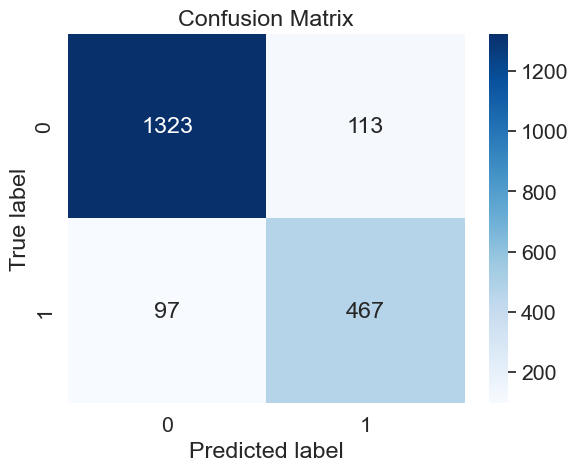

In [122]:
confusion_matrix_test = confusion_matrix(y_test_2, y_test_pred)
sns.set_theme(font_scale=1.4)
sns.heatmap(confusion_matrix_test, annot=True, fmt='g', cmap='Blues')
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion Matrix')
plt.show()

### Выводы задачи 2

- разделили признаки на группы: 
	- для кодирования с использованием OneHotEncoder;
	- для кодирования с использованием OrdinalEncoder;
	- для масштабирования;
- создали пайплайн;
- использовали RandomizedSearchCV для подбора наилучших параметров модели.

В качестве основной метрики для оценки модели использовалась метрика ROC AUC.

Наилучшие показатели были получены для модели дерева решений.

Для решения поставленной бизнес-задачи необходимо верно предсказывать значения, когда работник собирается уволиться. Т.е. нас интересует метрика TPR и ROC AUC, соответственно. 

Метрика F1 интересует с точки зрения точности с учетом дисбаланса классов. 

Значение метрики ROC-AUC на тестовой выборке равно 0.91. 

Значение метрики F1 на тестовой выборке равно 0.82. 

## Общий вывод

1. В рамках загрузки и предобработки данных:
- было выявлено некоторое количество пропущенных и пустых значений, которые были обработаны в рамках пайплайна (SimpleImputer);
- были удалены дубликаты в тренировочных данных.

2. В рамках исследовательского анализа данных:
- было выявлено, что целевой признак задачи 1 (уровень удовлетворенности, `job_satisfaction_rate`) распределен нормально, медианное значение равно 0.56;
- было выявлено, что целевой признак задачи 2 (увольнение работника, `quit`) имеет дисбаланс, который был учтен в рамках пайплайна (compute_class_weight);
- была выявлена зависимость между уровнем удовлетворенности работника и увольнением (чем ниже уровень удовлетворенности работой в компании у сотрудника, тем выше шанс того, что он уволится);
- был сформирован портрет уволившегося работника:
    - уровень занимаемой должности - junior
    - уровень загруженности - низкий (low)
    - без повышения за последний год
    - возможно, нарушивший трудовой договор
    - работает в компании менее 4 лет
    - оценка качества работы от руководителя - 3
    - ежемесячная зарплата ~ 24 000

3. В рамках корреляционного анализа данных:
- была выявлена заметная корреляция между оценкой от руководителя (`supervisor_evaluation`) и удовлетворенностью от работы (`job_satisfaction_rate`);
- была выявлена заметная корреляция между нарушением трудового договора (`last_year_violations`) и удовлетворенностью от работы (`job_satisfaction_rate`)
- была выявлена заметная корреляция между увольнением (`quit`) и количеством проработанных лет в компании (`employment_years`).
- была выявлена заметная корреляция между увольнением (`quit`) и уровнем зарплаты (`salary`).

4. В рамках обучения модели для решений задачи регрессии:
- были обучены модели линейной регрессии и дерева решений; 
- была создана новая метрика для оценки моделей - SMAPE;
- с помощью модели дерева решений удалось добиться лучших результатов на тестовой выборке (SMAPE < 15). 

5. В рамках обучения моделей для решений задачи классификации:
- использовали RandomizedSearchCV для подбора наилучших параметров;
- выбор осуществляли среди моделей:
    - LogisticRegression
    - KNeighborsClassifier
    - DecisionTreeClassifier
    - SVC
- было выявлено, что признак `dept` (отдел, в котором работает сотрудник), не является важным при моделировании;
- с помощью модели дерева решений удалось добиться лучших результатов на тестовой выборке (ROC_AUC > 0.91). 

**Рекомендации для бизнеса:**
1. Есть взаимосвязь между уровнем удовлетворенности сотрудника и его дальнейшим увольнением. 
2. Чтобы отследить уровень удовлетворенности работников, необходимо в первую очередь обращать внимание на уровень занимаемой должности и уровень зарплаты. Необходимо своевременно повышать работников и в должностях, и в зарплате. 
3. Особое внимание стоит уделять работникам, у которых было мало опыта при трудоустройстве и они приходили на позицию junior. Возможно стоит рассмотреть повышение таких работников, если их уровень компетенций вырос? Решение об этом может приниматься в результате, например, периодического тестирования.
4. Рекомендуется отслеживать загрузку работников и недопускать их простоя. Слишком много свободного времени влияет на решение уволиться. 